# Proyecto empresa aliada: entregable 3
En esta práctica, aplicarás técnicas de clustering para identificar segmentos clave en los que la marca Vanish tiene presencia, y podrás identificar áreas en las que mejorar su estrategia.

# 1. Cargar y preparar los datos:

- Carga el conjunto de datos relevante en un DataFrame de Pandas.

- Revisa los datos para identificar las columnas más relevantes que se utilizarán

In [2]:
print("\n" + "="*100)
print(" CARGA DE DATOS")
print("="*100)

# Librerías generales
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Librerías de visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Librerías de Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Configuración de visualización
plt.style.use('fivethirtyeight')
plt.rcParams['axes.unicode_minus'] = False

# Cargar DataFrame consolidado
df = pd.read_parquet('df_consolidado_final.parquet')

print(f"\n• Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"• Periodo: {df['DATE'].min().strftime('%Y-%m-%d')} a {df['DATE'].max().strftime('%Y-%m-%d')}")
print(f"• Ventas totales: ${df['TOTAL_VALUE_SALES'].sum():,.2f}")
print(f"• Valores nulos: {df.isnull().sum().sum()}")
print(f"• Filas duplicadas: {df.duplicated().sum()}")

print(f"\n• Columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col} ({df[col].dtype})")


 CARGA DE DATOS

• Dimensiones: 122,002 filas × 46 columnas
• Periodo: 2022-01-09 a 2023-07-17
• Ventas totales: $11,042,859.89
• Valores nulos: 0
• Filas duplicadas: 0

• Columnas disponibles:
   1. ITEM_CODE (object)
   2. MANUFACTURER (object)
   3. BRAND (object)
   4. ITEM_DESCRIPTION (object)
   5. ID_CATEGORY (int64)
   6. CATEGORY (object)
   7. SEGMENT (object)
   8. FORMAT (object)
   9. ATTR1 (object)
  10. ATTR2 (object)
  11. ATTR3 (object)
  12. SIZE (object)
  13. SIZE_NUM (float64)
  14. SIZE_UNIT (object)
  15. DATE (datetime64[ns])
  16. DAY_NUMBER (int32)
  17. DAY_NAME (object)
  18. WEEK_NUMBER (int64)
  19. WEEK_YEAR (object)
  20. MONTH (int64)
  21. MONTH_NAME (object)
  22. QUARTER (int32)
  23. YEAR_MONTH (object)
  24. YEAR_QUARTER (object)
  25. MONTH_PERIOD (category)
  26. YEAR (int64)
  27. REGION (object)
  28. REGION_CLEAN (object)
  29. REGION_SHORT (object)
  30. TOTAL_UNIT_SALES (float64)
  31. TOTAL_VALUE_SALES (float64)
  32. TOTAL_UNIT_AVG_WEEKLY

# 2. Seleccionar las características para el clustering:

- Elige las características clave que se utilizarán para segmentar los productos o regiones. Por ejemplo, puedes basarte en:

    - Ventas totales 

    - Categoría de producto 

    - Región geográfica 

    - Atributos específicos de los productos

## 2.1 Filtrar registros de la marca Vanish

El análisis se centra en **Vanish** para identificar sus segmentos de mercado internos y comparar su desempeño relativo frente al total del portafolio.

In [3]:
print("\n" + "="*100)
print(" FILTRO Y SELECCIÓN DE CARACTERÍSTICAS")
print("="*100)

# Filtrar Vanish
df_vanish = df[df['BRAND'].str.upper() == 'VANISH'].copy()

print(f"\n• Registros de Vanish: {len(df_vanish):,} de {len(df):,} totales ({len(df_vanish)/len(df)*100:.1f}%)")
print(f"• Ventas de Vanish: ${df_vanish['TOTAL_VALUE_SALES'].sum():,.2f}")
print(f"• Participación en ventas totales: {df_vanish['TOTAL_VALUE_SALES'].sum()/df['TOTAL_VALUE_SALES'].sum()*100:.1f}%")
print(f"\n• Segmentos en Vanish: {df_vanish['SEGMENT'].unique().tolist()}")
print(f"• Formatos en Vanish: {df_vanish['FORMAT'].unique().tolist()}")
print(f"• Regiones en Vanish: {df_vanish['REGION_SHORT'].unique().tolist()}")


 FILTRO Y SELECCIÓN DE CARACTERÍSTICAS

• Registros de Vanish: 28,377 de 122,002 totales (23.3%)
• Ventas de Vanish: $2,168,289.52
• Participación en ventas totales: 19.6%

• Segmentos en Vanish: ['Powder', 'Pretreat', 'Bar', 'Liquid & Gel']
• Formatos en Vanish: ['Polvo', 'Liquido', 'Barra', 'Gel']
• Regiones en Vanish: ['Area 5', 'Area 3', 'Area 2', 'Area 6', 'Area 1', 'Mexico', 'Area 4']


## 2.2 Ingeniería de características

Se construye una **tabla de agregación por producto-región** para condensar los 28,377 registros de Vanish en registros únicos.
Uno por cada combinación de producto (ITEM_CODE) + región (REGION_SHORT)

Las características elegidas capturan tres dimensiones complementarias:

| Dimensión | Variables |
|---|---|
| **Valor económico** | `sales_total`, `sales_mean`, `price_mean` |
| **Volumen / rotación** | `units_total`, `units_mean`, `weekly_avg_units` |
| **Comportamiento** | `var_pct_mean`, `above_avg_ratio`, `high_value_ratio`, `high_turnover_ratio` |

In [4]:
# Definir qué operación aplicar a cada columna al momento de agrupar
agg_dict = {
    'TOTAL_VALUE_SALES'          : ['sum', 'mean'],   # ingresos totales y promedio semanal del producto en esa región
    'TOTAL_UNIT_SALES'           : ['sum', 'mean'],   # unidades totales vendidas y promedio semanal
    'PRICE'                      : 'mean',            # precio promedio del producto en esa región durante el periodo
    'TOTAL_UNIT_AVG_WEEKLY_SALES': 'mean',            # Rrotación semanal promedio
    'VAR_PCT'                    : 'mean',            # variación porcentual promedio respecto al promedio general del mercado
    'ABOVE_AVG'                  : 'mean',            # ratio: proporción de semanas en que el producto estuvo por encima del promedio de ventas (0 a 1)
    'HIGH_VALUE'                 : 'mean',            # ratio: proporción de semanas clasificadas como alto valor en $ (high value = precio por encima de la mediana)
    'HIGH_TURNOVER'              : 'mean',            # ratio: proporción de semanas clasificado como alta rotación (high turnover = promedio de ventas semanal por encima de la mediana)
    'SEGMENT'                    : 'first',           # segmento del producto (toma el primer valor porque no cambia)
    'FORMAT'                     : 'first',           # formato del producto (toma el primer valor porque no cambia)
    'ITEM_CODE'                  : 'count'            # cuenta cuántas semanas tiene datos ese producto en esa región → n_weeks
}

# Agrupar por producto-región
df_agg = df_vanish.groupby(['ITEM_CODE', 'REGION_SHORT']).agg(agg_dict)

# Aplanar columnas multi-nivel (renombrar)
df_agg.columns = [
    'sales_total', 'sales_mean',
    'units_total', 'units_mean',
    'price_mean',
    'weekly_avg_units',
    'var_pct_mean',
    'above_avg_ratio',
    'high_value_ratio',
    'high_turnover_ratio',
    'segment', 'format',
    'n_weeks'
]

# Convertir ITEM_CODE y REGION_SHORT a columnas y renombrar
df_agg = df_agg.reset_index().rename(columns={
    'ITEM_CODE'    : 'item_code',
    'REGION_SHORT' : 'region'
})

# Verificar resultados
print("\n" + "="*100)
print(" AGREGACIÓN POR PRODUCTO-REGIÓN")
print("="*100)

print(f"\n• Registros en tabla de agregación: {len(df_agg):,}")
print(f"• Columnas: {df_agg.shape[1]}")
print(f"\n• Distribución por segmento:")
for seg, cnt in df_agg['segment'].value_counts().items():
    print(f"    {seg}: {cnt:,} ({cnt/len(df_agg)*100:.1f}%)")
print(f"\n• Distribución por región:")
for reg, cnt in df_agg['region'].value_counts().items():
    print(f"    {reg}: {cnt:,} ({cnt/len(df_agg)*100:.1f}%)")
print(f"\n• Primeras 5 filas:\n")
df_agg.head()


 AGREGACIÓN POR PRODUCTO-REGIÓN

• Registros en tabla de agregación: 479
• Columnas: 15

• Distribución por segmento:
    Liquid & Gel: 217 (45.3%)
    Powder: 199 (41.5%)
    Bar: 49 (10.2%)
    Pretreat: 14 (2.9%)

• Distribución por región:
    Mexico: 77 (16.1%)
    Area 2: 71 (14.8%)
    Area 1: 69 (14.4%)
    Area 6: 69 (14.4%)
    Area 4: 65 (13.6%)
    Area 3: 64 (13.4%)
    Area 5: 64 (13.4%)

• Primeras 5 filas:



,item_code,region,sales_total,sales_mean,units_total,units_mean,price_mean,weekly_avg_units,var_pct_mean,above_avg_ratio,high_value_ratio,high_turnover_ratio,segment,format,n_weeks
0,7501058712813,Area 1,3.887,0.111057,0.067,0.001914,57.922857,1.140457,-99.842857,0.0,1.000000,0.000000,Powder,Polvo,35
1,7501058712813,Area 2,3.152,0.098500,0.055,0.001719,57.203125,1.187500,-99.853125,0.0,1.000000,0.031250,Powder,Polvo,32
2,7501058712813,Area 3,3.470,0.119655,0.101,0.003483,54.720000,3.103448,-99.862069,0.0,0.896552,0.068966,Powder,Polvo,29
3,7501058712813,Area 4,0.059,0.059000,0.001,0.001000,59.000000,1.000000,-99.900000,0.0,1.000000,0.000000,Powder,Polvo,1
4,7501058712813,Area 5,2.322,0.136588,0.043,0.002529,53.374118,1.558824,-99.835294,0.0,1.000000,0.058824,Powder,Polvo,17


# 3. Estandarizar las características:

- Utiliza un método de escalado, como StandardScaler de Scikit-learn, para estandarizar las características seleccionadas. Esto es crucial, ya que K-Means se ve afectado por las diferentes escalas de los datos. Asegúrate de que todas las variables estén en la misma escala para obtener mejores resultados.

In [5]:
print("\n" + "="*100)
print(" ESTANDARIZACIÓN DE CARACTERÍSTICAS")
print("="*100)

# Características que alimentarán el modelo
features = [
    'sales_total',         # valor económico total
    'price_mean',          # posicionamiento de precio
    'units_total',         # volumen acumulado
    'weekly_avg_units',    # velocidad de rotación
    'var_pct_mean',        # desviación respecto al promedio del mercado
    'above_avg_ratio',     # consistencia de alto desempeño
    'high_value_ratio',    # proporción de semanas de alto valor
    'high_turnover_ratio', # proporción de semanas de alta rotación
    'n_weeks'              # número de semanas
]

X = df_agg[features].copy()

# Aplicar StandardScaler: media=0, desviación estándar=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n• Estadísticas de las características seleccionadas ({len(features)}):")
print(df_agg[features].describe().round(3).to_string())

print(f"\n• Valores antes de StandardScaler:")
print(f"    Media promedio original: {X.mean().mean():.6f}")
print(f"    Std promedio original: {X.std().mean():.6f}")

print(f"\n• Verificación después de StandardScaler:")
X_check = pd.DataFrame(X_scaled, columns=features)
print(f"    Media promedio (debe ser ≈0): {X_check.mean().mean():.6f}")
print(f"    Std promedio (debe ser ≈1): {X_check.std().mean():.6f}")
print(f"\n• Forma de la matriz escalada: {X_scaled.shape}")


 ESTANDARIZACIÓN DE CARACTERÍSTICAS

• Estadísticas de las características seleccionadas (9):
       sales_total  price_mean  units_total  weekly_avg_units  var_pct_mean  above_avg_ratio  high_value_ratio  high_turnover_ratio  n_weeks
count      479.000     479.000      479.000           479.000       479.000          479.000           479.000              479.000  479.000
mean      4526.700      70.478      115.518             5.063       -83.597            0.032             0.577                0.318   59.242
std       9932.287      59.477      363.120             6.440        33.597            0.169             0.480                0.398   29.258
min          0.007       0.000        0.000             0.100      -100.000            0.000             0.000                0.000    1.000
25%          7.046      21.555        0.226             2.009       -99.771            0.000             0.000                0.012   35.500
50%        733.204      53.000       11.318             2.7

# 4. Aplicar el algoritmo K-Means:

- Elige un número inicial de clusters (por ejemplo, 3 o 4) y aplica el algoritmo K-Means usando Scikit-learn.

- Realiza varias iteraciones con diferentes números de clusters para determinar cuál es el óptimo. Puedes utilizar el método del codo para evaluar qué número de clusters minimiza la suma de las distancias al centroide de cada cluster.

## 4.1 Método del Codo para determinar el k óptimo

In [6]:
print("\n" + "="*100)
print(" MÉTODO DEL CODO (INERCIA) Y TRES MÉTRICAS DE VALIDACIÓN")
print("="*100)

# Rango de clusters a evaluar
k_range = range(2, 11)

inertia    = []  # Sum of Squared Errors: suma de distancias al cuadrado de cada punto a su centroide → método del codo
silhouette = []  # Silhouette Score: qué tan similar es un punto a su propio cluster vs. al cluster más cercano
davies     = []  # Davies-Bouldin Index: ratio entre dispersión intra-cluster y separación inter-cluster
calinski   = []  # Calinski-Harabasz Index: ratio entre varianza inter-cluster e intra-cluster

print('\n  k    Inercia    Silhouette    Davies-Bouldin    Calinski-Harabasz')
print("─"*70)

# Para cada valor de k (de 2 a 10) entrenar un modelo KMeans
for k in k_range:
    km = KMeans(n_clusters=k, 
        init='k-means++', # Elige centroides iniciales separados entre sí (evita convergencia a mínimos locales malos)
        n_init=20,        # Repite el proceso 20 veces con diferentes puntos de partida y se queda con el mejor resultado
        random_state=42)  # Garantiza reproducibilidad
    
    labels = km.fit_predict(X_scaled)
    
    inertia.append(km.inertia_)                      # → menor es mejor
    sil = silhouette_score(X_scaled, labels)         # → -1 (peor) a +1 (mejor)
    db  = davies_bouldin_score(X_scaled, labels)     # → menor es mejor
    ch  = calinski_harabasz_score(X_scaled, labels)  # → mayor es mejor
    silhouette.append(sil)
    davies.append(db)
    calinski.append(ch)
    
    print(f"  {k}    {km.inertia_:>8,.2f}    {sil:>7.4f}    {db:>11.4f}    {ch:>15.2f}")


 MÉTODO DEL CODO (INERCIA) Y TRES MÉTRICAS DE VALIDACIÓN

  k    Inercia    Silhouette    Davies-Bouldin    Calinski-Harabasz
──────────────────────────────────────────────────────────────────────
  2    2,965.14     0.6929         0.7090             216.51
  3    2,090.38     0.3971         0.9702             252.83
  4    1,393.42     0.4370         0.8226             331.52
  5    1,186.10     0.4407         0.7850             312.20
  6    1,013.34     0.4347         0.8618             307.85
  7      858.51     0.4146         0.8455             316.36
  8      754.68     0.3869         0.9076             317.07
  9      670.23     0.3999         0.8755             319.14
  10      586.22     0.4162         0.8297             331.11


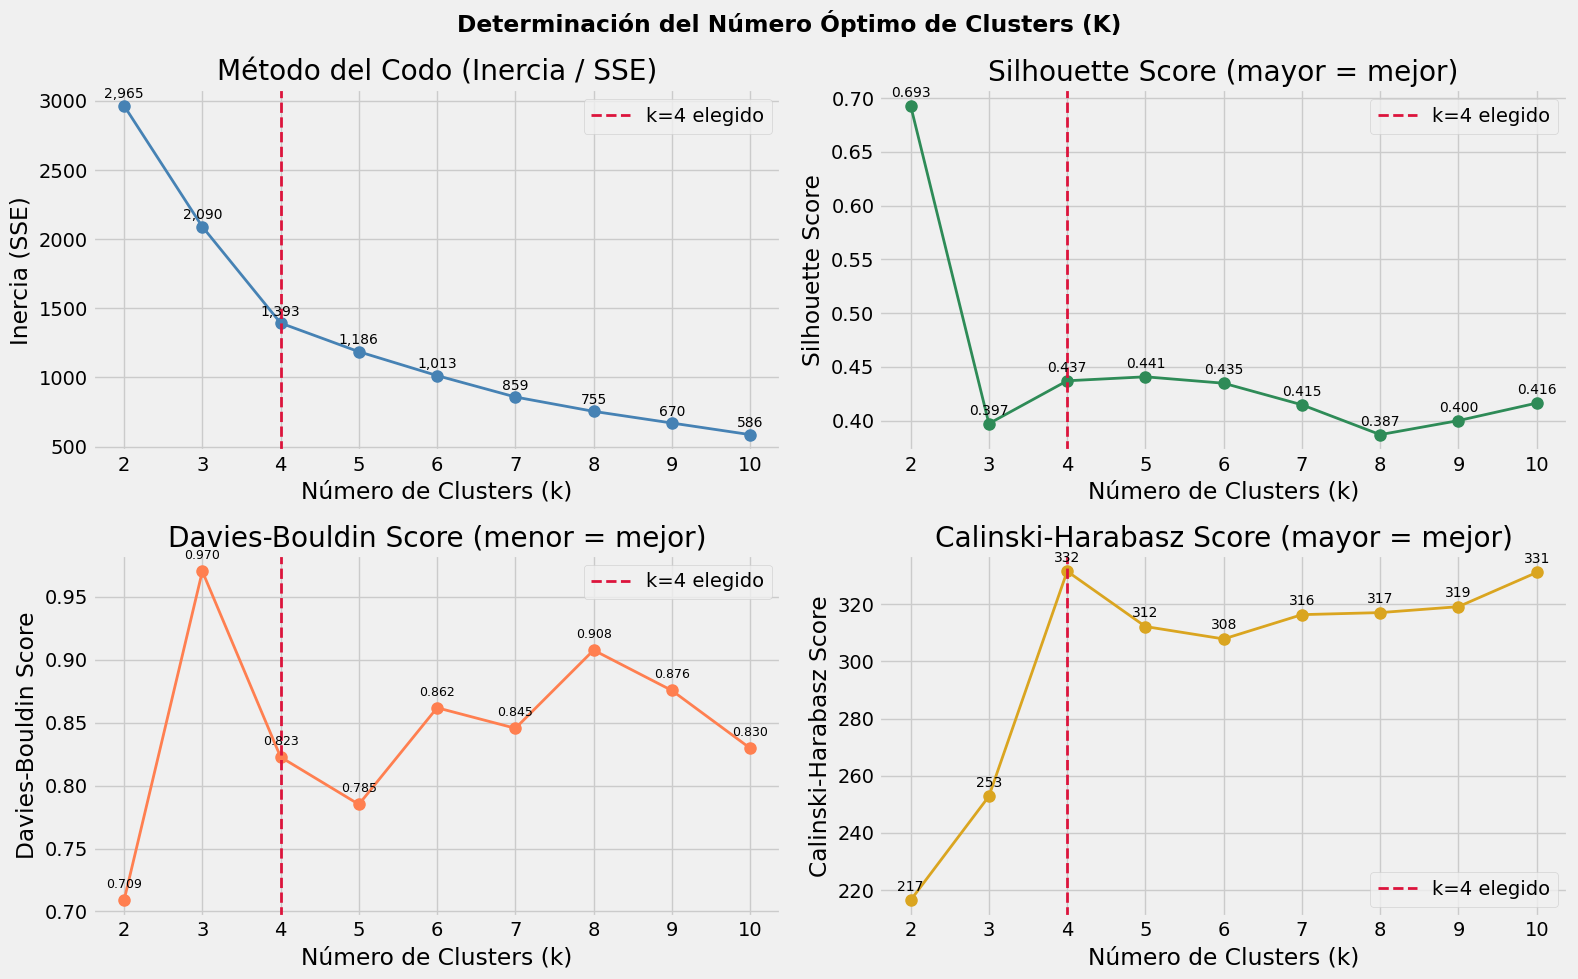


INSIGHTS DEL GRÁFICO 11: Método del Codo

• Análisis del Codo (Inercia):
    - La curva muestra la reducción más pronunciada entre k=2 y k=4.
    - A partir de k=4, la ganancia marginal de agregar un cluster adicional disminuye significativamente: 
      de k=4 a k=5 la inercia baja solo ~193 puntos, vs ~697 puntos de k=2 a k=4.
    - El punto de inflexión visible (el "codo") se ubica claramente en k=4.

• Silhouette Score:
    - El valor máximo absoluto se alcanza en k=2 (0.693), lo que sugiere que dos grandes grupos son muy distintos entre sí. 
      Sin embargo, k=2 es demasiado grueso para extraer insights de negocio útiles.
    - A partir de k=4 (0.437) el score se estabiliza en un rango aceptable (>0.38), 
      indicando clusters coherentes con mayor granularidad interpretativa.

• Davies-Bouldin Score:
    - El mínimo absoluto es k=2 (0.709), nuevamente por la misma razón: dos grupos muy distintos son fáciles de separar.
    - k=4 (0.823) y k=5 (0.785) ofrecen los mejores valo

In [7]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 11: Método del Codo + Métricas de Validación
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Determinación del Número Óptimo de Clusters (K)', fontweight='bold')

ks = list(k_range)

# ── Inercia (Elbow) ──
axes[0, 0].plot(ks, inertia, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].axvline(x=4, color='crimson', linestyle='--', linewidth=2, label='k=4 elegido')
axes[0, 0].set_title('Método del Codo (Inercia / SSE)')
axes[0, 0].set_xlabel('Número de Clusters (k)')
axes[0, 0].set_ylabel('Inercia (SSE)')
axes[0, 0].legend()
for k, val in zip(ks, inertia):
    axes[0, 0].text(k, val + max(inertia)*0.018, f'{val:,.0f}', ha='center', fontsize=10)

# ── Silhouette ──
axes[0, 1].plot(ks, silhouette, marker='o', linewidth=2, markersize=8, color='seagreen')
axes[0, 1].axvline(x=4, color='crimson', linestyle='--', linewidth=2, label='k=4 elegido')
axes[0, 1].set_title('Silhouette Score (mayor = mejor)')
axes[0, 1].set_xlabel('Número de Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()
for k, val in zip(ks, silhouette):
    axes[0, 1].text(k, val + max(silhouette)*0.012, f'{val:.3f}', ha='center', fontsize=10)

# ── Davies-Bouldin ──
axes[1, 0].plot(ks, davies, marker='o', linewidth=2, markersize=8, color='coral')
axes[1, 0].axvline(x=4, color='crimson', linestyle='--', linewidth=2, label='k=4 elegido')
axes[1, 0].set_title('Davies-Bouldin Score (menor = mejor)')
axes[1, 0].set_xlabel('Número de Clusters (k)')
axes[1, 0].set_ylabel('Davies-Bouldin Score')
axes[1, 0].legend()
for k, val in zip(ks, davies):
    axes[1, 0].text(k, val + max(davies)*0.01, f'{val:.3f}', ha='center', fontsize=9)

# ── Calinski-Harabasz ──
axes[1, 1].plot(ks, calinski, marker='o', linewidth=2, markersize=8, color='goldenrod')
axes[1, 1].axvline(x=4, color='crimson', linestyle='--', linewidth=2, label='k=4 elegido')
axes[1, 1].set_title('Calinski-Harabasz Score (mayor = mejor)')
axes[1, 1].set_xlabel('Número de Clusters (k)')
axes[1, 1].set_ylabel('Calinski-Harabasz Score')
axes[1, 1].legend()
for k, val in zip(ks, calinski):
    axes[1, 1].text(k, val + max(calinski)*0.01, f'{val:.0f}', ha='center', fontsize=10)
    
plt.tight_layout()
plt.savefig('11_metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════
#  INSIGHTS GRÁFICO 11: Método del Codo y 3 Métricas de Validación
# ════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("INSIGHTS DEL GRÁFICO 11: Método del Codo")
print("="*100)

print(f"""
• Análisis del Codo (Inercia):
    - La curva muestra la reducción más pronunciada entre k=2 y k=4.
    - A partir de k=4, la ganancia marginal de agregar un cluster adicional disminuye significativamente: 
      de k=4 a k=5 la inercia baja solo ~193 puntos, vs ~697 puntos de k=2 a k=4.
    - El punto de inflexión visible (el "codo") se ubica claramente en k=4.

• Silhouette Score:
    - El valor máximo absoluto se alcanza en k=2 (0.693), lo que sugiere que dos grandes grupos son muy distintos entre sí. 
      Sin embargo, k=2 es demasiado grueso para extraer insights de negocio útiles.
    - A partir de k=4 (0.437) el score se estabiliza en un rango aceptable (>0.38), 
      indicando clusters coherentes con mayor granularidad interpretativa.

• Davies-Bouldin Score:
    - El mínimo absoluto es k=2 (0.709), nuevamente por la misma razón: dos grupos muy distintos son fáciles de separar.
    - k=4 (0.823) y k=5 (0.785) ofrecen los mejores valores, siendo ambos soluciones razonables.

• Calinski-Harabasz Score:
    - Pico claro en k=4 (331.52), confirmando que esa solución maximiza la densidad intra-cluster y la separación inter-cluster simultáneamente.
    - Es la única métrica (además del codo) que señala k=4 de forma directa.

• Conclusión: k = 4 es el número óptimo de clusters.
    - El Codo y Calinski-Harabasz lo señalan directamente.
    - Silhouette y Davies-Bouldin favorecen k=2, pero ese valor ofrece muy poca granularidad para análisis de negocio.
    - k=4 coincide naturalmente con los 4 segmentos de producto de Vanish(Powder, Liquid & Gel, Bar, Pretreat), 
      lo que refuerza su validez desde la perspectiva comercial.
""")

## 4.2 Modelo K-Means final con k = 4

In [8]:
print("\n" + "="*100)
print("MODELO K-MEANS FINAL (k=4)")
print("="*100)

k_optimo = 4

# Modelo con k=4
kmeans_final = KMeans(
    n_clusters  = k_optimo,
    init        = 'k-means++',  # inicialización inteligente para convergencia más rápida
    n_init      = 50,           # 50 inicializaciones distintas para evitar mínimos locales
    max_iter    = 500,          # más iteraciones para asegurar convergencia default (300)
    random_state= 42
)

# Agregar cluster como columna
df_agg['cluster'] = kmeans_final.fit_predict(X_scaled) # fit → aprende los centroides de los 4 clusters a partir de X_scaled
                                                       # predict → asigna a cada fila el número del cluster más cercano (0, 1, 2 o 3)

# Métricas del modelo final
sil_final = silhouette_score(X_scaled, df_agg['cluster'])        # umbral mínimo aceptable > 0.25 
db_final  = davies_bouldin_score(X_scaled, df_agg['cluster'])    # umbral mínimo aceptable < 1.5
ch_final  = calinski_harabasz_score(X_scaled, df_agg['cluster'])

print(f"\n• k elegido                → {k_optimo}")
print(f"• Inercia final            → {kmeans_final.inertia_:,.2f}")
print(f"• Silhouette Score         → {sil_final:.4f} (objetivo > 0.25)")
print(f"• Davies-Bouldin Score     → {db_final:.4f} (objetivo < 1.5)")
print(f"• Calinski-Harabasz Score  → {ch_final:.2f}")

print(f"\n• Tamaño de los clusters:")
for c, cnt in df_agg['cluster'].value_counts().sort_index().items():
    print(f"    Cluster {c}: {cnt:>4} registros ({cnt/len(df_agg)*100:.1f}%)")


MODELO K-MEANS FINAL (k=4)

• k elegido                → 4
• Inercia final            → 1,393.42
• Silhouette Score         → 0.4370 (objetivo > 0.25)
• Davies-Bouldin Score     → 0.8226 (objetivo < 1.5)
• Calinski-Harabasz Score  → 331.52

• Tamaño de los clusters:
    Cluster 0:   16 registros (3.3%)
    Cluster 1:  161 registros (33.6%)
    Cluster 2:  205 registros (42.8%)
    Cluster 3:   97 registros (20.3%)


# 5. Evaluar los resultados del clustering:

- Revisa los resultados obtenidos y asigna cada producto o región a un cluster. Cada cluster debe representar un grupo de productos o regiones con características similares.

- Analiza las características de cada cluster y observa si hay patrones o segmentos que destacan en las ventas, categoría o región.

## 5.1 Perfiles de los clusters

In [9]:
print("\n" + "="*100)
print(" PERFILES DE LOS CLUSTERS")
print("="*100)

# Calcular centroide en escala original
centroides_originales = scaler.inverse_transform(kmeans_final.cluster_centers_)

df_centroides = pd.DataFrame(
    centroides_originales,
    columns=features
)

df_centroides.index.name = 'cluster'

print("\n• Valores promedio de cada cluster, en escala original:")
print(df_centroides.round(3).to_string())


# Resumen estadístico por cluster
print("\n\n" + "─"*70)
print(" RESUMEN ESTADÍSTICO POR CLUSTER")
print("─"*70)

metricas_cluster = df_agg.groupby('cluster').agg(
    # Cobertura y alcance
    n_registros         = ('item_code',           'count'),    # total de pares producto-región en el cluster
    productos_unicos    = ('item_code',           'nunique'),  # SKUs distintos que conforman el cluster
    regiones_unicas     = ('region',              'nunique'),  # áreas geográficas distintas con presencia

    # Ventas en $
    ventas_totales      = ('sales_total',         'sum'),      # suma total de ingresos del cluster en el periodo
    venta_media         = ('sales_total',         'mean'),     # ingreso promedio por combinación producto-región
    venta_semanal_med   = ('sales_mean',          'mean'),     # promedio de las ventas semanales

    # Precio
    precio_medio        = ('price_mean',          'mean'),     # precio medio de venta en el cluster

    # Volumen
    unidades_totales    = ('units_total',         'sum'),      # suma de unidades vendidas en todo el periodo
    unidades_media      = ('units_total',         'mean'),     # unidades promedio por combinación producto-región

    # Velocidad de movimiento
    rotacion_sem_media  = ('weekly_avg_units',    'mean'),     # unidades promedio vendidas por semana

    # Desempeño relativo al mercado
    variacion_mercado   = ('var_pct_mean',        'mean'),     # variación % promedio vs el promedio general del mercado
    ratio_sobre_media   = ('above_avg_ratio',     'mean'),     # proporción de semanas en que superó el promedio del mercado
    ratio_alto_valor    = ('high_value_ratio',    'mean'),     # proporción de semanas clasificadas como alto valor en $
    ratio_alta_rotacion = ('high_turnover_ratio', 'mean'),     # proporción de semanas clasificadas como alta rotación

    # Presencia temporal
    semanas_promedio    = ('n_weeks',             'mean')      # semanas con datos disponibles en promedio
).round(3)

clusters = sorted(metricas_cluster.index)

print(f"\n  {'Métrica':<22} " + "  ".join([f"Cluster {c:>1} " for c in clusters]))
print("─"*70)

for col in metricas_cluster.columns:
    vals = "  ".join([f"{metricas_cluster.loc[c, col]:>10.3f}" for c in clusters])
    print(f"  {col:<19} {vals}")


 PERFILES DE LOS CLUSTERS

• Valores promedio de cada cluster, en escala original:
         sales_total  price_mean  units_total  weekly_avg_units  var_pct_mean  above_avg_ratio  high_value_ratio  high_turnover_ratio  n_weeks
cluster                                                                                                                                       
0          47195.764      62.050     1404.843            10.191        68.469            0.920             0.606                0.693   79.750
1             34.212      30.307        1.622             1.985       -99.270           -0.000             0.263                0.111   26.379
2           4084.376     123.924       33.391             2.848       -87.013            0.002             0.993                0.136   74.751
3           5879.920      25.590      265.455            14.009       -75.445            0.003             0.215                0.984   77.629


────────────────────────────────────────────────────────

## 5.2 Asignar nombres descriptivos a los clusters según sus perfiles

In [10]:
# Los nombres se asignan después de revisar los centroides

cluster_nombres = {
    0: 'Alto Rendimiento',       # ventas máximas, único cluster con var_pct positivo
    1: 'Presencia Marginal',     # ventas mínimas, pocas semanas, bajo desempeño
    2: 'Premium Alto Valor',     # precio más alto, 99% semanas de alto valor $ 
    3: 'Mercado Masivo'          # precio bajo, mayor rotación y unidades
}
cluster_colores = {
    0: '#6d904f',     # verde: desempeño fuerte
    1: '#fc4f30',     # rojo: bajo desempeño
    2: '#008fd5',     # azul: premium / alto valor
    3: '#e5ae38'      # amarillo: volumen / rotación
}

df_agg['cluster_nombre'] = df_agg['cluster'].map(cluster_nombres)
df_agg['cluster_color']  = df_agg['cluster'].map(cluster_colores)

print("\n" + "="*100)
print(" MAPPING DE CLUSTERS")
print("="*100)

for c, nombre in cluster_nombres.items():
    print(f"\n  Cluster {c} → '{nombre}'")
    print(f"    - Registros producto-región : {metricas_cluster.loc[c, 'n_registros']:,.0f}")
    print(f"    - Ventas acumuladas         : ${metricas_cluster.loc[c, 'ventas_totales']:,.2f}")
    print(f"    - Unidades acumuladas       : {metricas_cluster.loc[c, 'unidades_totales']:,.2f}")
    print(f"    - Precio promedio           : ${metricas_cluster.loc[c, 'precio_medio']:,.2f}")
    print(f"    - Rotación semanal promedio : {metricas_cluster.loc[c, 'rotacion_sem_media']:,.2f} uds/semana")
    print(f"    - Variación vs mercado      : {metricas_cluster.loc[c, 'variacion_mercado']:+.1f}%")
    print(f"    - Semanas sobre promedio    : {metricas_cluster.loc[c, 'ratio_sobre_media']*100:.1f}%")
    print(f"    - Semanas alto valor        : {metricas_cluster.loc[c, 'ratio_alto_valor']*100:.1f}%")
    print(f"    - Semanas alta rotación     : {metricas_cluster.loc[c, 'ratio_alta_rotacion']*100:.1f}%")
    print(f"    - Presencia temporal        : {metricas_cluster.loc[c, 'semanas_promedio']:.0f} semanas promedio")


print("\n" + "="*100)
print(" INTERPRETACIÓN DE LOS CLUSTERS")
print("="*100)

print(f"""
Los 479 registros producto-región de la marca Vanish fueron agrupados en 4 clusters mediante K-Means, 
cada uno con un perfil de desempeño diferenciado.

────────────────────────────────────────────────────────────────────────────
  Cluster 0 · ALTO RENDIMIENTO  ({(df_agg['cluster']==0).sum()} combinaciones · ${df_agg[df_agg['cluster']==0]['sales_total'].sum():,.0f} en ventas)
────────────────────────────────────────────────────────────────────────────
  • Es el cluster más pequeño en número de registros (16), pero el más potente en términos de desempeño individual. 
  • Concentra el mayor ingreso promedio por combinación producto-región (${metricas_cluster.loc[0,'venta_media']:,.0f}) y es el único grupo con variación 
    positiva respecto al mercado (+{metricas_cluster.loc[0,'variacion_mercado']:.1f}%), lo que indica que vende consistentemente por encima del promedio.
  • El 92% de sus semanas se clasificaron como sobre el promedio de mercado.
  • Todos sus registros se concentran en una sola región, lo que puede representar tanto una fortaleza local 
    como una oportunidad de expansión geográfica.

────────────────────────────────────────────────────────────────────────────
  Cluster 1 · PRESENCIA MARGINAL  ({(df_agg['cluster']==1).sum()} combinaciones · ${df_agg[df_agg['cluster']==1]['sales_total'].sum():,.0f} en ventas)
────────────────────────────────────────────────────────────────────────────
  • Agrupa la mayor cantidad de combinaciones producto-región (161), pero con el desempeño más bajo del portafolio. 
  • Su venta promedio es de apenas ${metricas_cluster.loc[1,'venta_media']:,.2f} por combinación y su variación versus el mercado es de {metricas_cluster.loc[1,'variacion_mercado']:.1f}%, 
    prácticamente sin semanas sobre el promedio.
  • Su presencia temporal es limitada: solo {metricas_cluster.loc[1,'semanas_promedio']:.0f} semanas en promedio frente a las ~80 del resto de clusters, 
    lo que sugiere productos con distribución inconstante o reciente. 
  • Representa la principal área de mejora en la estrategia de portafolio de Vanish.

────────────────────────────────────────────────────────────────────────────
  Cluster 2 · PREMIUM ALTO VALOR  ({(df_agg['cluster']==2).sum()} combinaciones · ${df_agg[df_agg['cluster']==2]['sales_total'].sum():,.0f} en ventas)
────────────────────────────────────────────────────────────────────────────
  • Es el cluster más numeroso (205 registros) y el de mayor contribución total al ingreso (${df_agg[df_agg['cluster']==2]['sales_total'].sum():,.0f}). 
  • Se distingue por tener el precio promedio más alto (${metricas_cluster.loc[2,'precio_medio']:,.2f}) y por clasificarse en la categoría de alto valor económico 
   (precio por encima de la mediana) el {metricas_cluster.loc[2,'ratio_alto_valor']*100:.1f}% de las semanas. 
  • Sin embargo, su rotación es la más baja del portafolio ({metricas_cluster.loc[2,'rotacion_sem_media']:.2f} unidades/semana), lo que es coherente con un perfil premium: 
    vende caro, no necesariamente rápido.
  • Concentra la mayor parte de los ingresos de Vanish y representa el segmento de mayor retorno económico por unidad vendida.

────────────────────────────────────────────────────────────────────────────
  Cluster 3 · MERCADO MASIVO  ({(df_agg['cluster']==3).sum()} combinaciones · ${df_agg[df_agg['cluster']==3]['sales_total'].sum():,.0f} en ventas)
────────────────────────────────────────────────────────────────────────────
  • Define el extremo opuesto al Cluster 2: precio más bajo del portafolio(${metricas_cluster.loc[3,'precio_medio']:,.2f}), pero la mayor rotación semanal ({metricas_cluster.loc[3,'rotacion_sem_media']:.2f} unidades/semana)
    y el mayor volumen acumulado de unidades ({metricas_cluster.loc[3,'unidades_totales']:,.0f} unidades totales).
  • El {metricas_cluster.loc[3,'ratio_alta_rotacion']*100:.1f}% de sus semanas se clasificaron como de alta rotación.
  • Este cluster garantiza presencia y movimiento constante en anaquel, siendo clave para mantener visibilidad de la marca, 
    aunque con menor margen por unidad que el segmento Premium.
""")


 MAPPING DE CLUSTERS

  Cluster 0 → 'Alto Rendimiento'
    - Registros producto-región : 16
    - Ventas acumuladas         : $755,132.22
    - Unidades acumuladas       : 22,477.49
    - Precio promedio           : $62.05
    - Rotación semanal promedio : 10.19 uds/semana
    - Variación vs mercado      : +68.5%
    - Semanas sobre promedio    : 92.0%
    - Semanas alto valor        : 60.6%
    - Semanas alta rotación     : 69.3%
    - Presencia temporal        : 80 semanas promedio

  Cluster 1 → 'Presencia Marginal'
    - Registros producto-región : 161
    - Ventas acumuladas         : $5,508.13
    - Unidades acumuladas       : 261.20
    - Precio promedio           : $30.31
    - Rotación semanal promedio : 1.99 uds/semana
    - Variación vs mercado      : -99.3%
    - Semanas sobre promedio    : 0.0%
    - Semanas alto valor        : 26.3%
    - Semanas alta rotación     : 11.1%
    - Presencia temporal        : 26 semanas promedio

  Cluster 2 → 'Premium Alto Valor'
    - Regi

# 6. Visualizar los clusters:

- Crea gráficos de dispersión utilizando Matplotlib o Seaborn para visualizar cómo los productos o regiones se agrupan en función de las características seleccionadas. Usa colores para diferenciar los clusters y añade etiquetas para identificar los productos o regiones clave dentro de cada uno.

- Genera gráficos adicionales, como gráficos de barras o diagramas de caja, para explorar más a fondo los resultados del clustering.

## 6.1 PCA 2D: Dispersión de clusters en espacio reducido

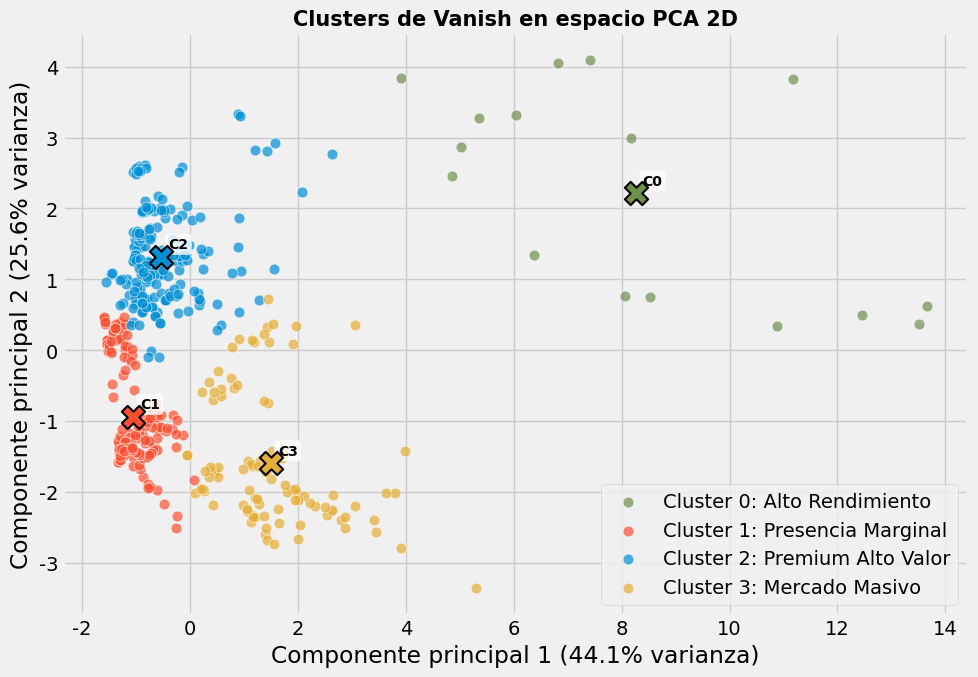


 INSIGHTS DEL GRÁFICO 12: PCA 2D

 • Varianza explicada por PCA:
     PC1: 44.1%
     PC2: 25.6%
     Total: 69.7%

• Se observa una separación visual razonable entre varios clusters, especialmente en torno a sus centroides, aunque existe cierto solapamiento 
  entre grupos cercanos. Esto es esperable en datos comerciales, donde los perfiles de producto-región no son completamente discretos.

• Los centroides marcados con "X" representan el perfil promedio de cada cluster en el espacio reducido por PCA y ayudan a identificar 
  la posición central de cada grupo.

• Es normal que la separación en el gráfico 2D no sea perfecta, ya que K-Means fue entrenado sobre 9 variables estandarizadas, mientras que PCA 
  resume esa información en solo 2 componentes. Por ello, parte de la separación real entre clusters puede perderse en la proyección.

• El gráfico confirma que la solución de 4 clusters captura patrones diferenciados y visualmente interpretables dentro del portafolio de Vanish.



In [11]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 12: Scatter PCA 2D
# ══════════════════════════════════════════════════════════════

# Reducir dimensionalidad para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_explicada = pca.explained_variance_ratio_
var_total = varianza_explicada.sum()

df_agg['pca1'] = X_pca[:, 0]
df_agg['pca2'] = X_pca[:, 1]

# Proyectar centroides al espacio PCA
centroides_pca = pca.transform(kmeans_final.cluster_centers_)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 7))

for c in sorted(df_agg['cluster'].unique()):
    mask = df_agg['cluster'] == c
    ax.scatter(
        df_agg.loc[mask, 'pca1'], df_agg.loc[mask, 'pca2'],
        color=cluster_colores[c],
        label=f"Cluster {c}: {cluster_nombres[c]}",
        alpha=0.70, s=60, edgecolors='white', linewidth=0.5)
    
# Centroides
for c in sorted(df_agg['cluster'].unique()):
    ax.scatter(
        centroides_pca[c, 0], centroides_pca[c, 1],
        color=cluster_colores[c], marker='X', s=280,
        edgecolors='black', linewidth=1.5, zorder=5)
    ax.text(
        centroides_pca[c, 0] + 0.12, centroides_pca[c, 1] + 0.12,
        f"C{c}", fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8))
    
# Etiquetas y nombres
ax.set_title('Clusters de Vanish en espacio PCA 2D', fontweight='bold', fontsize=15)
ax.set_xlabel(f'Componente principal 1 ({varianza_explicada[0]*100:.1f}% varianza)')
ax.set_ylabel(f'Componente principal 2 ({varianza_explicada[1]*100:.1f}% varianza)')
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.savefig('12_scatter_pca_clusters.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*100)
print(" INSIGHTS DEL GRÁFICO 12: PCA 2D")
print("="*100)

print(f"""
 • Varianza explicada por PCA:
     PC1: {varianza_explicada[0]*100:.1f}%
     PC2: {varianza_explicada[1]*100:.1f}%
     Total: {var_total*100:.1f}%

• Se observa una separación visual razonable entre varios clusters, especialmente en torno a sus centroides, aunque existe cierto solapamiento 
  entre grupos cercanos. Esto es esperable en datos comerciales, donde los perfiles de producto-región no son completamente discretos.

• Los centroides marcados con "X" representan el perfil promedio de cada cluster en el espacio reducido por PCA y ayudan a identificar 
  la posición central de cada grupo.

• Es normal que la separación en el gráfico 2D no sea perfecta, ya que K-Means fue entrenado sobre 9 variables estandarizadas, mientras que PCA 
  resume esa información en solo 2 componentes. Por ello, parte de la separación real entre clusters puede perderse en la proyección.

• El gráfico confirma que la solución de 4 clusters captura patrones diferenciados y visualmente interpretables dentro del portafolio de Vanish.
""")

## 6.2 Ventas totales por cluster: Barras

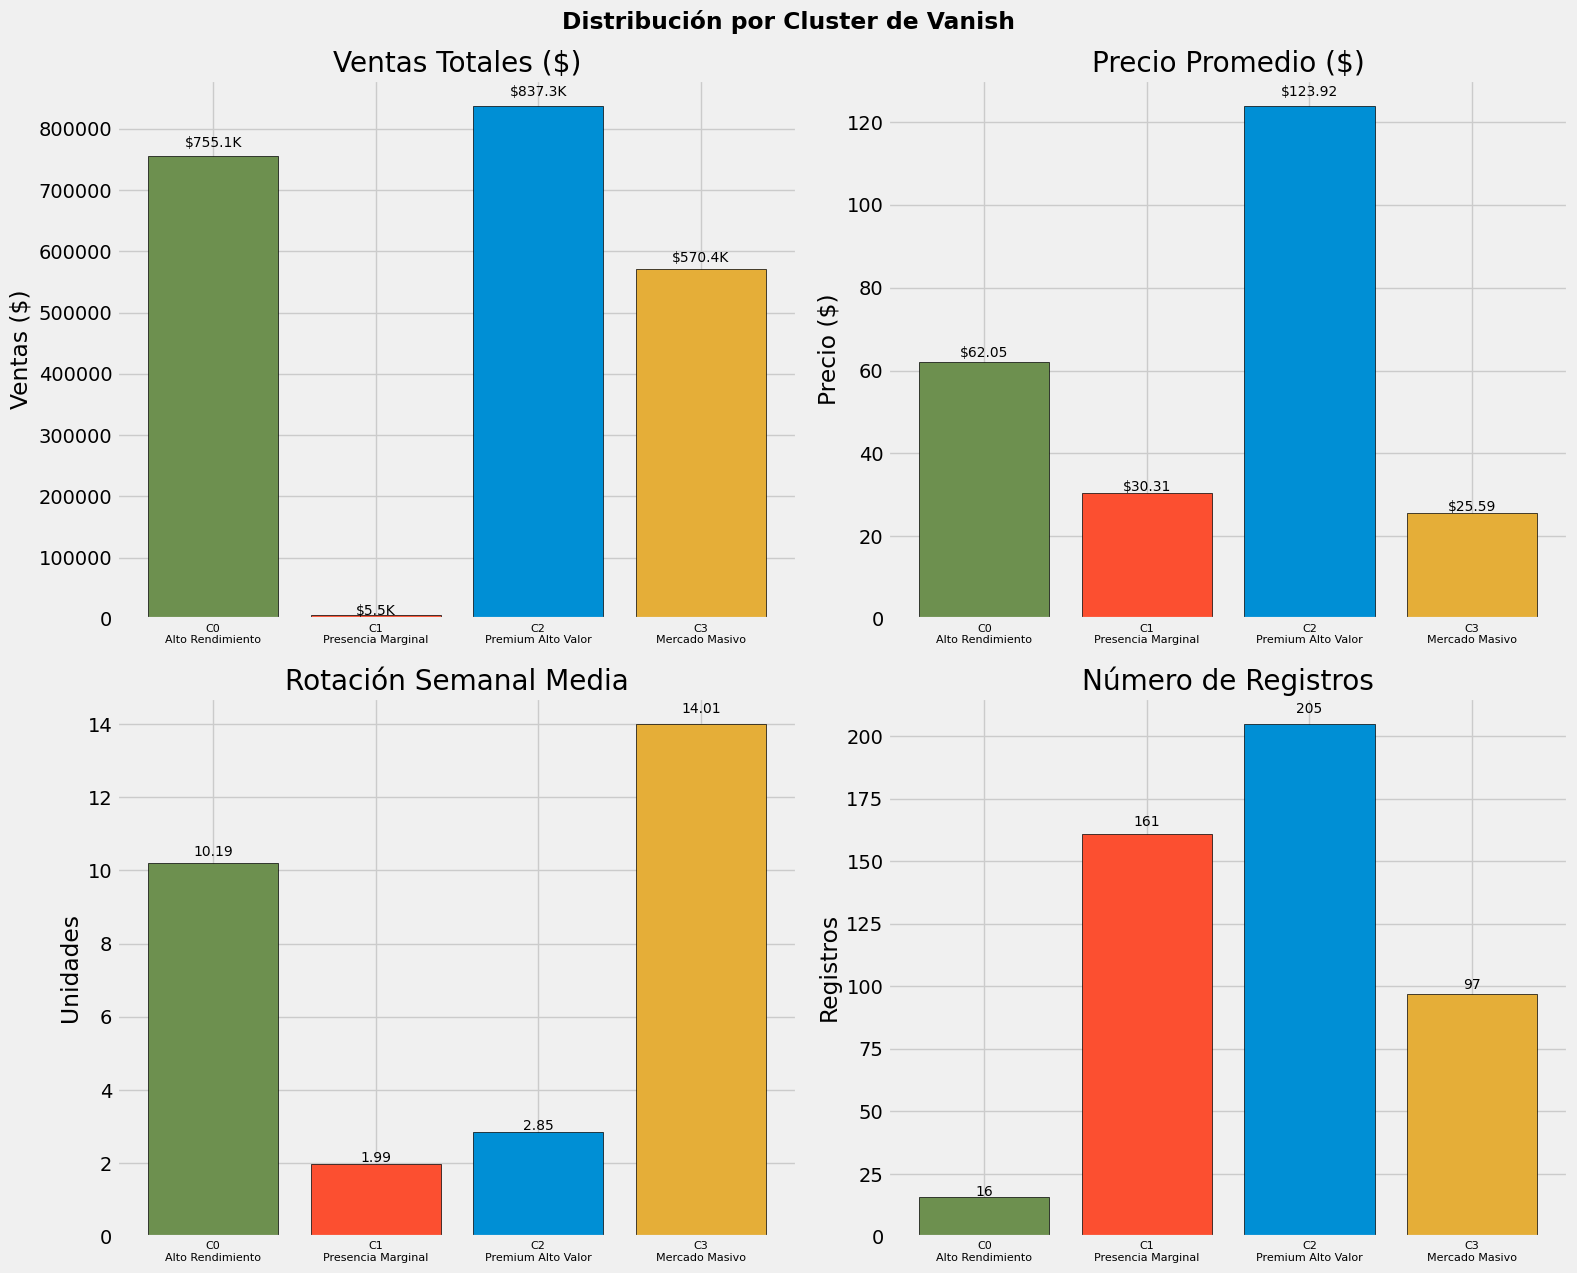


 INSIGHTS DEL GRÁFICO 13: Distribución por Cluster

  Cluster 0: Alto Rendimiento
    Registros      → 16
    Ventas totales → $755,132.22 (34.8% del total Vanish)
    Precio medio   → $62.05
    Rotación media → 10.19 unidades/semana

  Cluster 1: Presencia Marginal
    Registros      → 161
    Ventas totales → $5,508.13 (0.3% del total Vanish)
    Precio medio   → $30.31
    Rotación media → 1.99 unidades/semana

  Cluster 2: Premium Alto Valor
    Registros      → 205
    Ventas totales → $837,296.98 (38.6% del total Vanish)
    Precio medio   → $123.92
    Rotación media → 2.85 unidades/semana

  Cluster 3: Mercado Masivo
    Registros      → 97
    Ventas totales → $570,352.20 (26.3% del total Vanish)
    Precio medio   → $25.59
    Rotación media → 14.01 unidades/semana


In [12]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 13: Distribución de Ventas y Registros por Cluster
# ══════════════════════════════════════════════════════════════

ventas_cluster = df_agg.groupby(['cluster', 'cluster_nombre']).agg(
    ventas_totales = ('sales_total', 'sum'),
    n_registros = ('item_code', 'count'),
    precio_medio = ('price_mean', 'mean'),
    rotacion_sem_media = ('weekly_avg_units', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Distribución por Cluster de Vanish', fontweight='bold')

etiquetas = [f"C{r['cluster']}\n{r['cluster_nombre']}" for _, r in ventas_cluster.iterrows()]
colores_c = [cluster_colores[r['cluster']] for _, r in ventas_cluster.iterrows()]

# ── Ventas Totales ──
bars = axes[0,0].bar(etiquetas, ventas_cluster['ventas_totales'], color=colores_c, edgecolor='black')
axes[0,0].set_title('Ventas Totales ($)')
axes[0,0].set_ylabel('Ventas ($)')
for bar, v in zip(bars, ventas_cluster['ventas_totales']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                 f'${v/1e3:.1f}K', ha='center', fontsize=10)
plt.setp(axes[0,0].get_xticklabels(), fontsize=8)

# ── Precio Promedio ──
bars1 = axes[0,1].bar(etiquetas, ventas_cluster['precio_medio'], color=colores_c, edgecolor='black')
axes[0,1].set_title('Precio Promedio ($)')
axes[0,1].set_ylabel('Precio ($)')
for bar, v in zip(bars1, ventas_cluster['precio_medio']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                 f'${v:.2f}', ha='center', fontsize=10)
plt.setp(axes[0,1].get_xticklabels(), fontsize=8)

# ── Rotación Semanal Media ──
bars2 = axes[1,0].bar(etiquetas, ventas_cluster['rotacion_sem_media'], color=colores_c, edgecolor='black')
axes[1,0].set_title('Rotación Semanal Media')
axes[1,0].set_ylabel('Unidades')
for bar, v in zip(bars2, ventas_cluster['rotacion_sem_media']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                 f'{v:.2f}', ha='center', fontsize=10)
plt.setp(axes[1,0].get_xticklabels(), fontsize=8)

# ── Número de Registros ──
bars3 = axes[1,1].bar(etiquetas, ventas_cluster['n_registros'], color=colores_c, edgecolor='black')
axes[1,1].set_title('Número de Registros')
axes[1,1].set_ylabel('Registros')
for bar, v in zip(bars3, ventas_cluster['n_registros']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                 str(v), ha='center', fontsize=10)
plt.setp(axes[1,1].get_xticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig('13_ventas_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*100)
print(" INSIGHTS DEL GRÁFICO 13: Distribución por Cluster")
print("="*100)
for _, row in ventas_cluster.iterrows():
    pct = row['ventas_totales'] / ventas_cluster['ventas_totales'].sum() * 100
    print(f"\n  Cluster {row['cluster']}: {row['cluster_nombre']}")
    print(f"    Registros      → {row['n_registros']}")
    print(f"    Ventas totales → ${row['ventas_totales']:,.2f} ({pct:.1f}% del total Vanish)")
    print(f"    Precio medio   → ${row['precio_medio']:.2f}")
    print(f"    Rotación media → {row['rotacion_sem_media']:.2f} unidades/semana")

## 6.3 Heatmap de perfiles de clusters

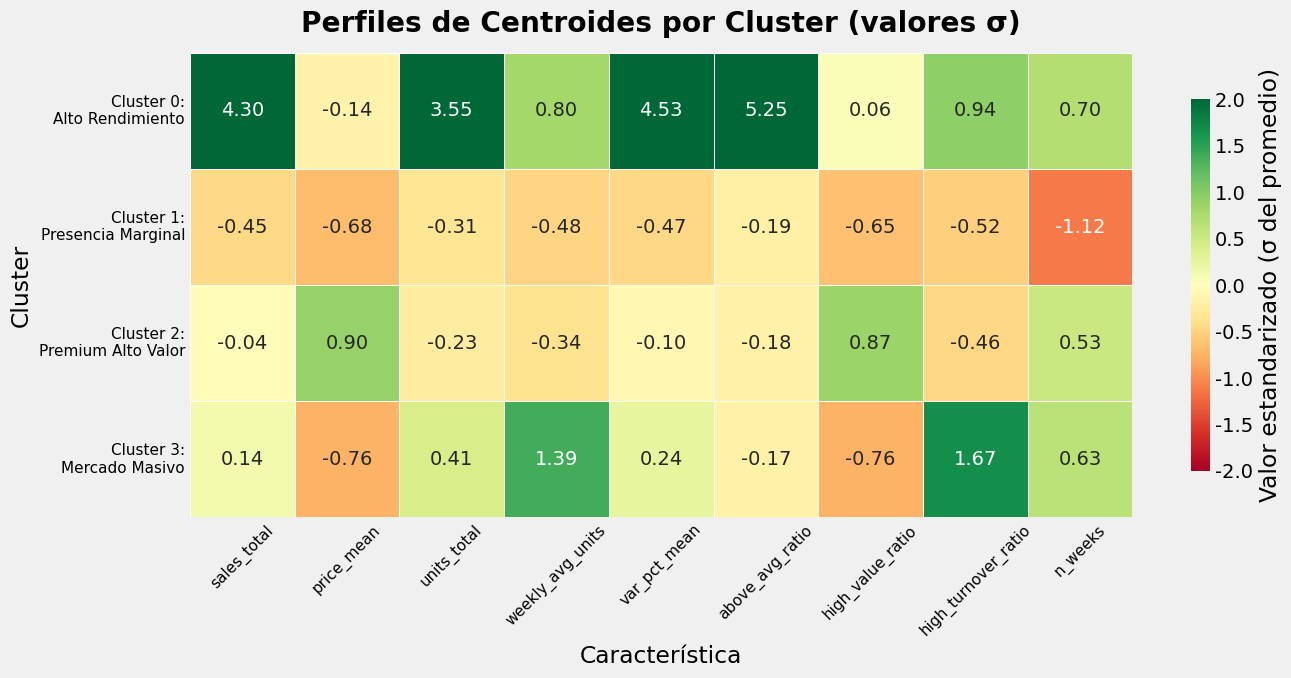


 INSIGHTS DEL GRÁFICO 14: Heatmap de Perfiles

Lectura: Verde = valor alto (por encima del promedio), Rojo = valor bajo (por debajo).
Los números son desviaciones estándar (σ) respecto al promedio de la muestra.

 Cluster 0: Alto Rendimiento
    • Es el único con valores extremadamente altos (>4σ) en sales_total, units_total, var_pct_mean y above_avg_ratio.
    • Representa el top de desempeño con ventas de muchas unidades y una relevancia estadística muy superior al promedio. 
    • Son el motor principal de la marca.

 Cluster 1: Presencia Marginal
    • Casi toda la fila está en tonos naranjas y rojos (valores negativos). El valor más bajo está en n_weeks (-1.12).
    • Productos con desempeño pobre y baja continuidad. Se venden poco, tienen precios bajos y están presentes en el mercado 
      durante mucho menos tiempo que los demás. 
    • Podrían ser SKUs en descontinuación o lanzamientos fallidos.

 Cluster 2: Premium Alto Valor
    • Destaca en price_mean (0.90) y high_value_r

In [13]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 14: Heatmap de Perfiles de Clusters (Valores Estandarizados)
# ══════════════════════════════════════════════════════════════

# Usar centroides estandarizados para el heatmap (permite comparar sin escala)
centroides_df = pd.DataFrame(kmeans_final.cluster_centers_, columns=features,
                             index=[f"Cluster {c}:\n{cluster_nombres[c]}" for c in range(k_optimo)])

# Gráfico
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(centroides_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-2, vmax=2, 
            linewidths=0.5, cbar_kws={'label': 'Valor estandarizado (σ del promedio)', 'shrink': 0.8}, ax=ax)

ax.set_title('Perfiles de Centroides por Cluster (valores σ)', fontweight='bold', pad=15)
ax.set_xlabel('Característica',)
ax.set_ylabel('Cluster')
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('14_heatmap_perfiles.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*100)
print(" INSIGHTS DEL GRÁFICO 14: Heatmap de Perfiles")
print("="*100)
print(f"""
Lectura: Verde = valor alto (por encima del promedio), Rojo = valor bajo (por debajo).
Los números son desviaciones estándar (σ) respecto al promedio de la muestra.

 Cluster 0: Alto Rendimiento
    • Es el único con valores extremadamente altos (>4σ) en sales_total, units_total, var_pct_mean y above_avg_ratio.
    • Representa el top de desempeño con ventas de muchas unidades y una relevancia estadística muy superior al promedio. 
    • Son el motor principal de la marca.

 Cluster 1: Presencia Marginal
    • Casi toda la fila está en tonos naranjas y rojos (valores negativos). El valor más bajo está en n_weeks (-1.12).
    • Productos con desempeño pobre y baja continuidad. Se venden poco, tienen precios bajos y están presentes en el mercado 
      durante mucho menos tiempo que los demás. 
    • Podrían ser SKUs en descontinuación o lanzamientos fallidos.
    
 Cluster 2: Premium Alto Valor
    • Destaca en price_mean (0.90) y high_value_ratio (0.87). Sus ventas totales y unidades están cerca del promedio (cero).
    • Son pocas ventas con alta rentabilidad debido a que mantienen un precio superior y una alta proporción de ventas de alto valor 
      (precio por encima de la mediana).
    • Es el segmento de nicho premium. 

 Cluster 3: Mercado Masivo
    • Sobresale en weekly_avg_units (1.39) y high_turnover_ratio (1.67). Y tiene el price_mean más bajo (-0.76).
    • Son los líderes en rotación, aunque son productos de precio bajo (posiblemente sachets o formatos económicos), 
      entran y salen de los anaqueles constantemente. 
    • Son clave para generar tráfico y presencia de marca.
""")

## 6.4 Distribución por segmento y región dentro de cada cluster

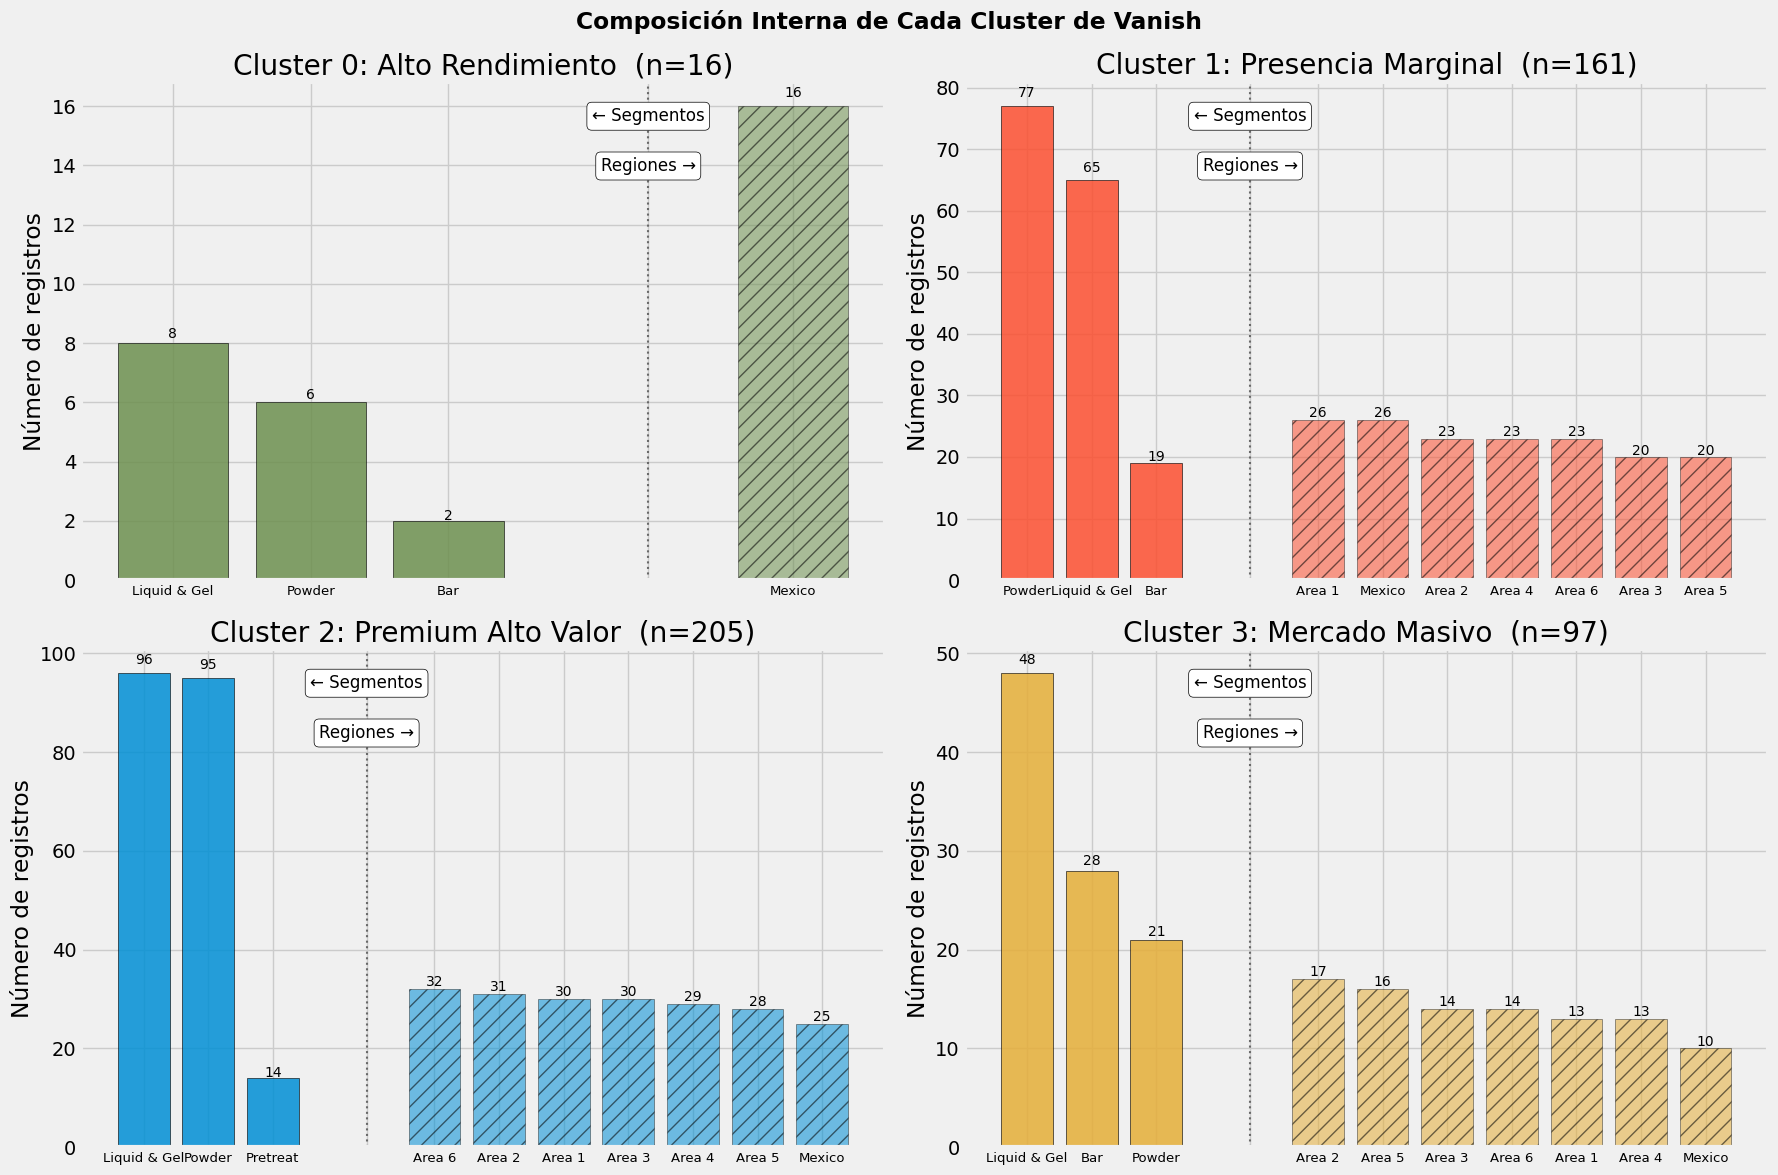


 INSIGHTS DEL GRÁFICO 15: Composición Interna de Clusters

 Cluster 0: Alto Rendimiento (n=16)
    • Composición: dominado por Liquid & Gel (8) y Powder (6)
    • Geografía: el 100% de estos registros pertenecen a la región Mexico (16)
    • Área de oportunidad para replicar este éxito en otras regiones

 Cluster 1: Presencia Marginal (n=161)
    • Composición: único cluster con el formato Powder (77) como el más común, seguido por Liquid & Gel (65)
    • Geografía: distribuido en todas las regiones, con una ligera ventaja en Area 1 y Mexico
    • Son productos con distribución equilibrada regionalmente, aunque con baja eficiencia de venta

 Cluster 2: Premium Alto Valor (n=205)
    • Composición: casi empate entre Liquid & Gel (96) y Powder (95), y único cluster con el segmento Pretreat (14) y sin el segmento Bar
    • Geografía: equilibrado en todas las regiones, liderado ligeramente por Area 6 (32), con México como la región más baja (25)
    • Oportunidad para revisar el éxito Pre

In [14]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 15: Composición por Segmento y Región en cada Cluster
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Composición Interna de Cada Cluster de Vanish', fontweight='bold')

# Gráfico de barras para cada cluster
for c in range(k_optimo):            # Recorre desde 0 hasta k_optimo-1 = 4 clusters
    ax = axes[c // 2][c % 2]         # Acomoda cada cluster en su fila y columna
    mask = df_agg['cluster'] == c    # Máscara para seleccionar solo las filas del DF del cluster
    df_c = df_agg[mask]              # Aplica máscara y crea sub DF con los registros del cluster
    
    # Distribución por segmento y por región
    seg_counts = df_c['segment'].value_counts()
    reg_counts = df_c['region'].value_counts()

    # Posicionamiento dual en X
    x_seg = np.arange(len(seg_counts))
    x_reg = np.arange(len(reg_counts)) + len(seg_counts) + 1.5  # Deja espacio para que no se encimen las barras

    # Estilo para las barras
    bars1 = ax.bar(x_seg, seg_counts.values, color=cluster_colores[c], alpha=0.85, edgecolor='black', label='Segmentos')
    bars2 = ax.bar(x_reg, reg_counts.values, color=cluster_colores[c], alpha=0.55, edgecolor='black', hatch='//', label='Regiones')

    # Valores sobre las barras
    for bar, v in zip(bars1, seg_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02, str(v), ha='center', fontsize=10)
    for bar, v in zip(bars2, reg_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02, str(v), ha='center', fontsize=10)
    
    # Etiquetas del eje X
    all_labels = list(seg_counts.index) + [''] + list(reg_counts.index)
    all_x = list(x_seg) + [len(seg_counts) + 0.45] + list(x_reg)
    ax.set_xticks(all_x)
    ax.set_xticklabels(all_labels, fontsize=9.5)
    
    ax.set_title(f"Cluster {c}: {cluster_nombres[c]}  (n={mask.sum()})")
    ax.set_ylabel('Número de registros')
    
    # Separador visual entre segmentos y regiones
    ax.axvline(x=len(seg_counts) + 0.45, color='dimgray', linestyle=':', linewidth=1.5)
    ax.text(len(seg_counts) + 0.45, ax.get_ylim()[1]*0.85, 'Regiones →',
            ha='center', va='top', fontsize=12, color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))
    ax.text(len(seg_counts) + 0.45, ax.get_ylim()[1]*0.95, '← Segmentos',
            ha='center', va='top', fontsize=12, color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))

plt.tight_layout()
plt.savefig('15_composicion_clusters.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*100)
print(" INSIGHTS DEL GRÁFICO 15: Composición Interna de Clusters")
print("="*100)
print(f"""
 Cluster 0: Alto Rendimiento (n=16)
    • Composición: dominado por Liquid & Gel (8) y Powder (6)
    • Geografía: el 100% de estos registros pertenecen a la región Mexico (16)
    • Área de oportunidad para replicar este éxito en otras regiones
      
 Cluster 1: Presencia Marginal (n=161)
    • Composición: único cluster con el formato Powder (77) como el más común, seguido por Liquid & Gel (65)
    • Geografía: distribuido en todas las regiones, con una ligera ventaja en Area 1 y Mexico
    • Son productos con distribución equilibrada regionalmente, aunque con baja eficiencia de venta
    
 Cluster 2: Premium Alto Valor (n=205)
    • Composición: casi empate entre Liquid & Gel (96) y Powder (95), y único cluster con el segmento Pretreat (14) y sin el segmento Bar
    • Geografía: equilibrado en todas las regiones, liderado ligeramente por Area 6 (32), con México como la región más baja (25)
    • Oportunidad para revisar el éxito Pretreat como segmento premium

 Cluster 3: Mercado Masivo (n=97)
    • Composición: fuerte predominio de Liquid & Gel (48) con el ~%50, la otra mitad lo conforman los segmentos Bar (28) y Powder (21)
    • Geografía: liderado por Area 2 (17 )y Area 5 (16), presente en todas las regiones con México como la más baja (10)
    • El segmento Bar tiene mayor volumen que en todos los clusters, lo que sugiere su éxito de venta masiva
""")

## 6.5 Boxplot de ventas por cluster

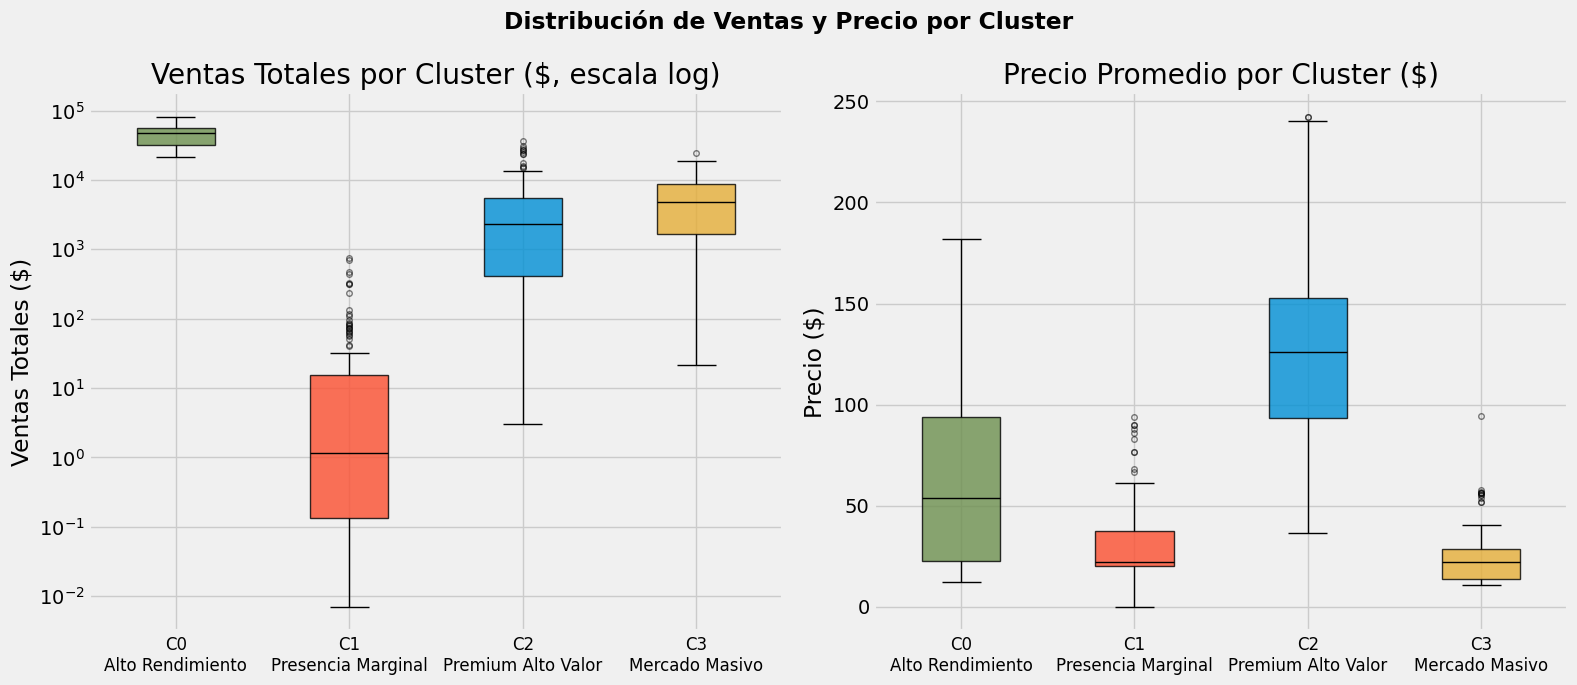


 INSIGHTS DEL GRÁFICO 16: Boxplot de Ventas y Precio

La escala logarítmica es vital aquípara poder comparar clusters con datos tan variados: 
el Cluster 0 está en el rango de 10^4 a 10^5, mientras que el Cluster 1 cae hasta 10^-2 
Sin esta escala, las cajas de C1, C2 y C3 no se podrían visualizar

Cluster 0: Alto Rendimiento (Verde)
    • Ventas: es el líder. Su caja (el 50% central de los datos) es la que está más arriba y separada del resto
    • Precio: la caja es muy alta, lo que indica tiene una gran dispersión en precios

 Cluster 1: Presencia Marginal (Rojo)
    • Ventas: su mediana está cerca de $1, esto confirma que es el "piso" del negocio con las menores ventas, aunque tenga outliers hacia arriba
    • Precio: precios bajos y concentrados, con varios outliers superiores

 Cluster 2: Premium Alto Valor (Azul)
    • Ventas: tiene una dispersión alta hacia arriba (outliers). Hay algunos SKUs específicos que logran ventas destacadas
    • Precio: es el líder. Su mediana de pre

In [15]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 16: Boxplot de Ventas por Cluster
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distribución de Ventas y Precio por Cluster', fontweight='bold')

# ── Boxplot Ventas totales ──
cluster_data_sales = [df_agg[df_agg['cluster'] == c]['sales_total'].values for c in range(k_optimo)] # lista de las ventas de cada cluster
bp1 = axes[0].boxplot(
    cluster_data_sales,
    patch_artist=True, # permite rellenar las cajas con color
    medianprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch, c in zip(bp1['boxes'], range(k_optimo)): # itera sobre cada caja del boxplot y le asigna un color según el cluster
    patch.set_facecolor(cluster_colores[c])
    patch.set_alpha(0.8)
axes[0].set_yscale('log') # escala logarítmica para visualizar todos los boxplots
axes[0].set_xticklabels([f"C{c}\n{cluster_nombres[c]}" for c in range(k_optimo)], fontsize=12)
axes[0].set_title('Ventas Totales por Cluster ($, escala log)')
axes[0].set_ylabel('Ventas Totales ($)')

# ── Boxplot Precio ──
cluster_data_price = [df_agg[df_agg['cluster'] == c]['price_mean'].values for c in range(k_optimo)] # lista de los precios de cada cluster
bp2 = axes[1].boxplot(
    cluster_data_price,
    patch_artist=True,
    medianprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
for patch, c in zip(bp2['boxes'], range(k_optimo)):
    patch.set_facecolor(cluster_colores[c])
    patch.set_alpha(0.8)
axes[1].set_xticklabels([f"C{c}\n{cluster_nombres[c]}" for c in range(k_optimo)], fontsize=12)
axes[1].set_title('Precio Promedio por Cluster ($)')
axes[1].set_ylabel('Precio ($)')

plt.tight_layout()
plt.savefig('16_boxplot_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*100)
print(" INSIGHTS DEL GRÁFICO 16: Boxplot de Ventas y Precio")
print("="*100)
print(f"""
La escala logarítmica es vital aquípara poder comparar clusters con datos tan variados: 
el Cluster 0 está en el rango de 10^4 a 10^5, mientras que el Cluster 1 cae hasta 10^-2 
Sin esta escala, las cajas de C1, C2 y C3 no se podrían visualizar

Cluster 0: Alto Rendimiento (Verde)
    • Ventas: es el líder. Su caja (el 50% central de los datos) es la que está más arriba y separada del resto
    • Precio: la caja es muy alta, lo que indica tiene una gran dispersión en precios
      
 Cluster 1: Presencia Marginal (Rojo)
    • Ventas: su mediana está cerca de $1, esto confirma que es el "piso" del negocio con las menores ventas, aunque tenga outliers hacia arriba
    • Precio: precios bajos y concentrados, con varios outliers superiores
    
 Cluster 2: Premium Alto Valor (Azul)
    • Ventas: tiene una dispersión alta hacia arriba (outliers). Hay algunos SKUs específicos que logran ventas destacadas
    • Precio: es el líder. Su mediana de precio de ~$125 es la más alta
    
 Cluster 3: Mercado Masivo (Amarillo)
    • Ventas: es el segundo grupo más importante en ingresos. Su caja es compacta, lo que indica un flujo de ventas predecible y estable
    • Precio: tiene el precio más bajo y uniforme. Son los productos de entrada o formatos pequeños que garantizan la presencia de la marca
""")

## 6.6 Análisis Cruzado de Vanish VS Mercado

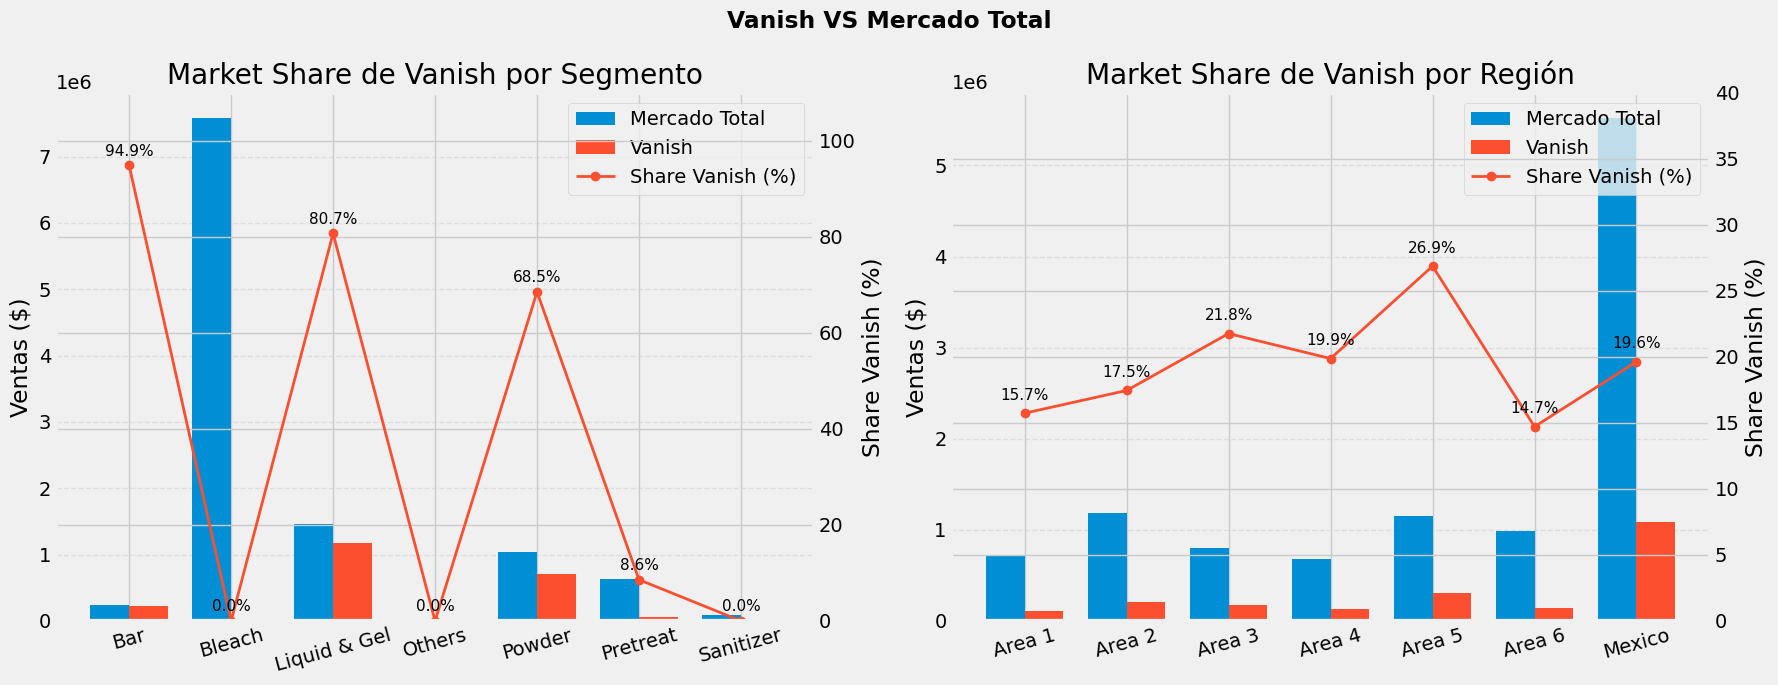


 INSIGHTS DEL GRÁFICO 17: Vanish VS Mercado Total por Segmento y Región

Market Share de Vanish por Segmento:
─────────────────────────────────────────────────────────────────
  Segmento        Mercado Total        Vanish     Share Vanish
─────────────────────────────────────────────────────────────────
  Bar             $  243,539.23    $  231,055.62      94.9%
  Bleach          $7,581,283.77    $        0.00       0.0%
  Liquid & Gel    $1,454,056.07    $1,173,610.26      80.7%
  Others          $   15,041.42    $        0.00       0.0%
  Powder          $1,035,021.68    $  709,377.89      68.5%
  Pretreat        $  632,002.03    $   54,245.76       8.6%
  Sanitizer       $   81,915.70    $        0.00       0.0%
─────────────────────────────────────────────────────────────────

Market Share de Vanish por Región:
─────────────────────────────────────────────────────────────────
  Región          Mercado Total        Vanish     Share Vanish
───────────────────────────────────────────

In [16]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 17: Vanish VS Mercado Total por Segmento y Región
# ══════════════════════════════════════════════════════════════

# # Market Share de Vanish por segmento
ventas_seg_total = df.groupby('SEGMENT')['TOTAL_VALUE_SALES'].sum()              # Ventas totales del mercado por segmento
ventas_seg_vanish = df_vanish.groupby('SEGMENT')['TOTAL_VALUE_SALES'].sum()      # Ventas totales de Vanish por segmento

share_seg = (ventas_seg_vanish / ventas_seg_total * 100).fillna(0)               # Porcentaje de ventas de Vanish de las ventas totales por segmento

# # Market Share de Vanish por región
ventas_reg_total = df.groupby('REGION_SHORT')['TOTAL_VALUE_SALES'].sum()         # Ventas totales del mercado por región
ventas_reg_vanish = df_vanish.groupby('REGION_SHORT')['TOTAL_VALUE_SALES'].sum() # Ventas totales de Vanish por región

share_reg = (ventas_reg_vanish / ventas_reg_total * 100).fillna(0)               # Porcentaje de ventas de Vanish de las ventas totales por región

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ─── MARKET SHARE POR SEGMENTO ───
ax1 = axes[0]
x = np.arange(len(ventas_seg_total.index))
width = 0.38

# Barras
bars1 = ax1.bar(x - width/2,ventas_seg_total.values, width, label='Mercado Total')
bars2 = ax1.bar(x + width/2,ventas_seg_vanish.reindex(ventas_seg_total.index, fill_value=0).values, width, label='Vanish')

# Eje secundario para %
ax1b = ax1.twinx()
ax1b.plot(x, share_seg.reindex(ventas_seg_total.index, fill_value=0).values, marker='o', linewidth=2, c='#fc4f30', label='Share Vanish (%)')

# Etiquetas %
for i, val in enumerate(share_seg.reindex(ventas_seg_total.index, fill_value=0).values):
    ax1b.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=11)

# Configuración
ax1.set_title('Market Share de Vanish por Segmento')
ax1.set_xticks(x)
ax1.set_xticklabels(ventas_seg_total.index, rotation=15)
ax1.set_ylabel('Ventas ($)')
ax1b.set_ylabel('Share Vanish (%)')
ax1b.set_ylim(0, 110)

ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# ─── MARKET SHARE POR REGIÓN ───
ax2 = axes[1]
x2 = np.arange(len(ventas_reg_total.index))

# Barras
bars3 = ax2.bar(x2 - width/2, ventas_reg_total.values, width, label='Mercado Total')
bars4 = ax2.bar(x2 + width/2, ventas_reg_vanish.reindex(ventas_reg_total.index, fill_value=0).values, width, label='Vanish')

# Eje secundario %
ax2b = ax2.twinx()
ax2b.plot(x2, share_reg.reindex(ventas_reg_total.index, fill_value=0).values, marker='o', linewidth=2, c='#fc4f30', label='Share Vanish (%)')

# Etiquetas %
for i, val in enumerate(share_reg.reindex(ventas_reg_total.index, fill_value=0).values):
    ax2b.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=11)

# Configuración
ax2.set_title('Market Share de Vanish por Región')
ax2.set_xticks(x2)
ax2.set_xticklabels(ventas_reg_total.index, rotation=15)
ax2.set_ylabel('Ventas ($)')
ax2b.set_ylabel('Share Vanish (%)')
ax2b.set_ylim(0, 40)

ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Leyenda combinada
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()

ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')


fig.suptitle('Vanish VS Mercado Total', weight='bold')
plt.tight_layout()
plt.savefig("17_vanish_market_share.png", dpi=150, bbox_inches="tight")
plt.show()


print("\n" + "="*100)
print(" INSIGHTS DEL GRÁFICO 17: Vanish VS Mercado Total por Segmento y Región")
print("="*100)

print("\nMarket Share de Vanish por Segmento:")
print("─"*65)
print(f"  {'Segmento':<13} {'Mercado Total':>15} {'Vanish':>13} {'Share Vanish':>16}")
print("─"*65)
for seg in ventas_seg_total.index:
    total   = ventas_seg_total.get(seg, 0)
    vanish  = ventas_seg_vanish.get(seg, 0)
    share   = (vanish / total * 100) if total > 0 else 0
    print(f"  {seg:<15} ${total:>12,.2f}    ${vanish:>12,.2f} {share:>9.1f}%")
print("─"*65)

print("\nMarket Share de Vanish por Región:")
print("─"*65)
print(f"  {'Región':<13} {'Mercado Total':>15} {'Vanish':>13} {'Share Vanish':>16}")
print("─"*65)
for reg in ventas_reg_total.index:
    total   = ventas_reg_total.get(reg, 0)
    vanish  = ventas_reg_vanish.get(reg, 0)
    share   = (vanish / total * 100) if total > 0 else 0
    print(f"  {reg:<15} ${total:>12,.2f}    ${vanish:>12,.2f} {share:>9.1f}%")
print("─"*65)

## 6.7 Clusters VS Market Share


  CLUSTERS VS MARKET SHARE: posición competitiva de Vanish por segmento y región

SHARE DE MERCADO DE VANISH POR CLUSTER Y SEGMENTO
(Share = ventas del cluster en ese segmento / ventas totales del mercado en ese segmento)
──────────────────────────────────────────────────────────────────────────────────────────────────
  Cluster Nombre            Segmento      Ventas Vanish   Mercado Total  Share Mercado  % dentro Vanish
──────────────────────────────────────────────────────────────────────────────────────────────────
  C0: Alto Rendimiento      Liquid & Gel   $449,323.28    $1,454,056.07     30.90%        38.29%
  C0: Alto Rendimiento      Powder         $212,574.10    $1,035,021.68     20.54%        29.97%
  C0: Alto Rendimiento      Bar            $ 93,234.84    $  243,539.23     38.28%        40.35%
──────────────────────────────────────────────────────────────────────────────────────────────────
  C1: Presencia Marginal    Powder         $  3,011.02    $1,035,021.68      0.29%   

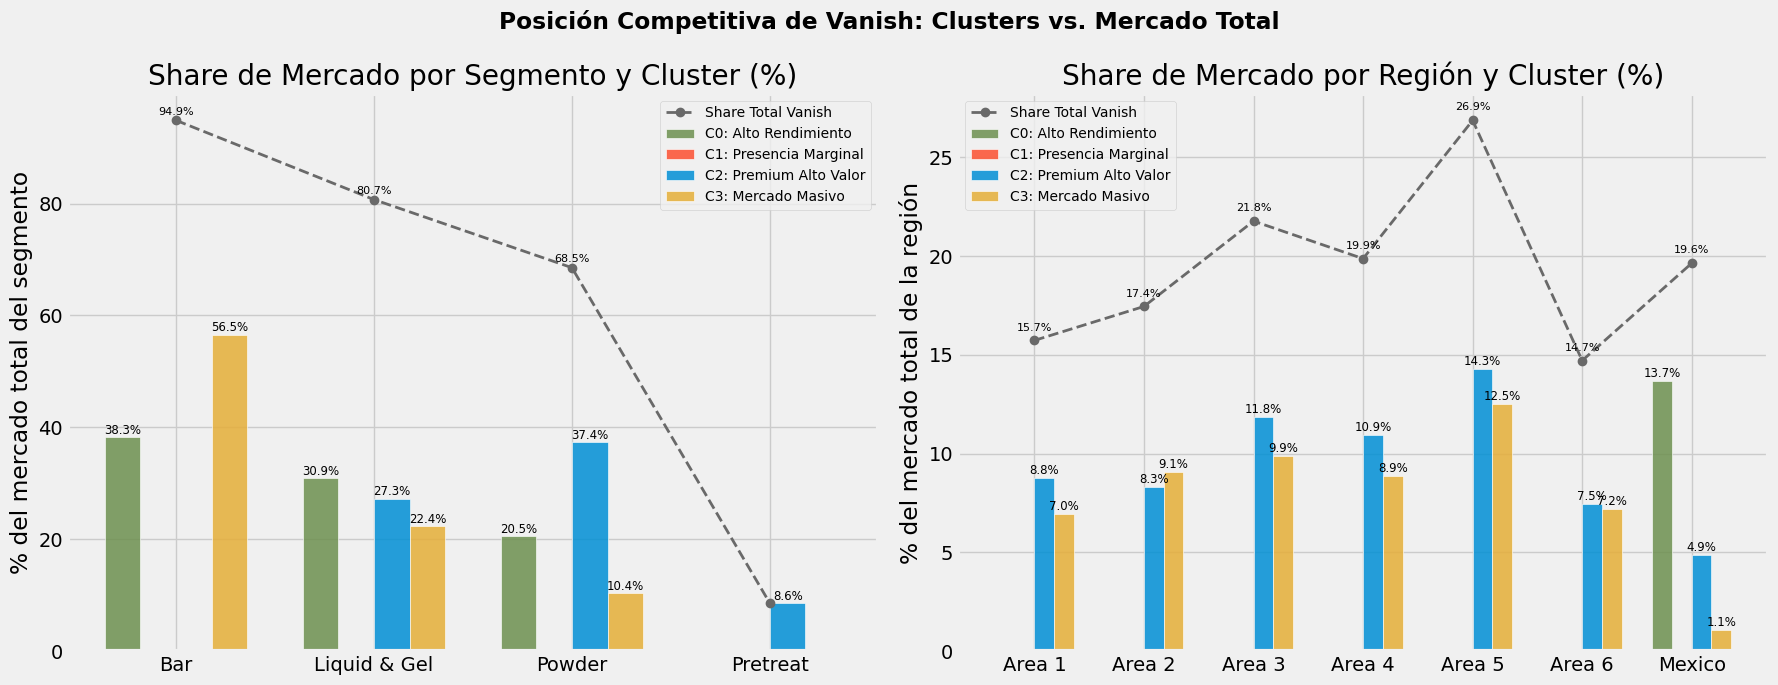


 INSIGHTS DEL GRÁFICO 18: Clusters VS Market Share

 • El clustering interno describe cómo se distribuye el portafolio dentro de Vanish
 • El market share agrega la perspectiva externa sobre cómo se posiciona cada cluster frente al mercado total
 • La combinación permite distinguir fortaleza interna (importancia para Vanish) de fortaleza competitiva (dominio frente al mercado)

─────────────────────────────────────────────────────────────────────────────────
 POSICIÓN DE VANISH EN EL MERCADO COMO REFERENCIA GENERAL
─────────────────────────────────────────────────────────────────────────────────

 • Share total de Vanish por segmento (suma de todos los clusters):
    Bar          → 94.87%
    Liquid & Gel → 80.71%
    Powder       → 68.54%
    Pretreat     → 8.58%
    Bleach       → sin presencia (0 registros)
    Others       → sin presencia (0 registros)
    Sanitizer    → sin presencia (0 registros)

 • Share total de Vanish por región:
    Area 5       → 26.87%
    Area 3       → 

In [37]:
print("\n" + "="*100)
print("  CLUSTERS VS MARKET SHARE: posición competitiva de Vanish por segmento y región")
print("="*100)

# ── Calcular shares de referencia (escala total de Vanish vs mercado) ───
share_vanish_total_seg = (df_vanish.groupby("SEGMENT")["TOTAL_VALUE_SALES"].sum() / 
                          df.groupby("SEGMENT")["TOTAL_VALUE_SALES"].sum() * 100).round(2)

share_vanish_total_reg = (df_vanish.groupby("REGION_SHORT")["TOTAL_VALUE_SALES"].sum() / 
                          df.groupby("REGION_SHORT")["TOTAL_VALUE_SALES"].sum() * 100).round(2)


# ─── Tabla 1: Share por segmento y cluster ───
vanish_seg_cluster = df_agg.groupby(["cluster", "cluster_nombre", "segment"])["sales_total"].sum().reset_index()
vanish_seg_cluster.columns = ["cluster", "cluster_nombre", "segment", "ventas_vanish_cluster"]

vanish_seg_cluster["ventas_mercado_seg"] = vanish_seg_cluster["segment"].map(ventas_seg_total)

vanish_seg_cluster["share_pct"] = (vanish_seg_cluster["ventas_vanish_cluster"] / 
                                   vanish_seg_cluster["ventas_mercado_seg"] * 100).round(2)

total_vanish_por_seg = vanish_seg_cluster.groupby("segment")["ventas_vanish_cluster"].sum()
vanish_seg_cluster["share_vanish_total_pct"] = (vanish_seg_cluster["ventas_vanish_cluster"] / 
                                                vanish_seg_cluster["segment"].map(total_vanish_por_seg) * 100).round(2)

print("\nSHARE DE MERCADO DE VANISH POR CLUSTER Y SEGMENTO")
print("(Share = ventas del cluster en ese segmento / ventas totales del mercado en ese segmento)")
print("─"*98)
print(f"  {'Cluster':<5} {'Nombre':<17} {'Segmento':<13} {'Ventas Vanish':>10}"
      f"  {'Mercado Total':>14} {'Share Mercado':>14} {'% dentro Vanish':>16}")
print("─"*98)

for c in sorted(vanish_seg_cluster["cluster"].unique()):
    sub = vanish_seg_cluster[vanish_seg_cluster["cluster"] == c].sort_values("ventas_vanish_cluster", ascending=False)
    nombre = sub["cluster_nombre"].iloc[0]
    for _, row in sub.iterrows():
        print(f"  C{row['cluster']}: {nombre:<21} {row['segment']:<14}"
              f" ${row['ventas_vanish_cluster']:>10,.2f}    ${row['ventas_mercado_seg']:>12,.2f}"
              f" {row['share_pct']:>9.2f}%  {row['share_vanish_total_pct']:>11.2f}%")
    print("─"*98)


# ─── Tabla 2: Share por región y cluster ───

vanish_reg_cluster = df_agg.groupby(["cluster", "cluster_nombre", "region"])["sales_total"].sum().reset_index()
vanish_reg_cluster.columns = ["cluster", "cluster_nombre", "region", "ventas_vanish_cluster"]

vanish_reg_cluster["ventas_mercado_reg"] = vanish_reg_cluster["region"].map(ventas_reg_total)

vanish_reg_cluster["share_pct"] = (
    vanish_reg_cluster["ventas_vanish_cluster"] /
    vanish_reg_cluster["ventas_mercado_reg"] * 100
).round(2)

total_vanish_por_reg = vanish_reg_cluster.groupby("region")["ventas_vanish_cluster"].sum()
vanish_reg_cluster["share_vanish_total_pct"] = (
    vanish_reg_cluster["ventas_vanish_cluster"] /
    vanish_reg_cluster["region"].map(total_vanish_por_reg) * 100
).round(2)

print("\nSHARE DE MERCADO DE VANISH POR CLUSTER Y REGIÓN")
print("(Share = ventas del cluster en esa región / ventas totales del mercado en esa región)")
print("─"*98)
print(f"  {'Cluster':<5} {'Nombre':<17} {'Región':<13} {'Ventas Vanish':>10}"
      f"  {'Mercado Total':>14} {'Share Mercado':>14} {'% dentro Vanish':>16}")
print("─"*98)

for c in sorted(vanish_reg_cluster["cluster"].unique()):
    sub = vanish_reg_cluster[vanish_reg_cluster["cluster"] == c].sort_values("ventas_vanish_cluster", ascending=False)
    nombre = sub["cluster_nombre"].iloc[0]
    for _, row in sub.iterrows():
        print(f"  C{row['cluster']}: {nombre:<21} {row['region']:<14}"
              f" ${row['ventas_vanish_cluster']:>10,.2f}    ${row['ventas_mercado_reg']:>12,.2f}"
              f" {row['share_pct']:>9.2f}%  {row['share_vanish_total_pct']:>11.2f}%")
    print("─"*98)


# ══════════════════════════════════════════════════════════════════
# GRÁFICO 18: Posición competitiva de Vanish por segmento y cluster
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Posición Competitiva de Vanish: Clusters vs. Mercado Total", fontweight="bold")
bar_width = 0.18

# ── Panel izquierdo: share por segmento ───
ax = axes[0]
segmentos_vanish = vanish_seg_cluster["segment"].unique()
x = np.arange(len(segmentos_vanish))
n_c = vanish_seg_cluster["cluster"].nunique()
offsets = np.linspace(-(n_c - 1) / 2, (n_c - 1) / 2, n_c) * bar_width

for idx, c in enumerate(sorted(vanish_seg_cluster["cluster"].unique())):
    sub = vanish_seg_cluster[vanish_seg_cluster["cluster"] == c].set_index("segment")
    valores = [sub.loc[seg, "share_pct"] if seg in sub.index else 0 for seg in segmentos_vanish]
    bars = ax.bar(x + offsets[idx], valores, width=bar_width,
                  color=cluster_colores[c], edgecolor="white", linewidth=0.5,
                  label=f"C{c}: {cluster_nombres[c]}", alpha=0.85)
    for bar, v in zip(bars, valores):
        if v > 0.3:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f"{v:.1f}%", ha="center", va="bottom", fontsize=8.5)

# Línea share total Vanish (referencia competitiva)
share_total_seg = [share_vanish_total_seg.get(seg, 0) for seg in segmentos_vanish]
ax.plot(x, share_total_seg, color="dimgray", linestyle="--", marker="o",
        linewidth=2, label="Share Total Vanish")
for xi, yi, seg in zip(x, share_total_seg, segmentos_vanish):
    if seg != "Pretreat":  # sin Pretreat, la línea coincide con C2 al 100% (etiqueta redundante)
        ax.text(xi, yi + 1, f"{yi:.1f}%", ha="center", fontsize=8, color="black")

ax.set_xticks(x)
ax.set_xticklabels(segmentos_vanish)
ax.set_title("Share de Mercado por Segmento y Cluster (%)")
ax.set_ylabel("% del mercado total del segmento")
ax.legend(fontsize=10, loc="upper right")

# ── Panel derecho: share por región ───
ax2 = axes[1]
regiones_vanish = sorted(vanish_reg_cluster["region"].unique())
x2 = np.arange(len(regiones_vanish))
n_r = vanish_reg_cluster["cluster"].nunique()
offsets2 = np.linspace(-(n_r - 1) / 2, (n_r - 1) / 2, n_r) * bar_width

for idx, c in enumerate(sorted(vanish_reg_cluster["cluster"].unique())):
    sub = vanish_reg_cluster[vanish_reg_cluster["cluster"] == c].set_index("region")
    valores = [sub.loc[reg, "share_pct"] if reg in sub.index else 0 for reg in regiones_vanish]
    bars2 = ax2.bar(x2 + offsets2[idx], valores, width=bar_width,
                    color=cluster_colores[c], edgecolor="white", linewidth=0.5,
                    label=f"C{c}: {cluster_nombres[c]}", alpha=0.85)
    for bar, v in zip(bars2, valores):
        if v > 0.3:
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                     f"{v:.1f}%", ha="center", va="bottom", fontsize=8.5)

# Línea share total Vanish por región
share_total_reg = [share_vanish_total_reg.get(reg, 0) for reg in regiones_vanish]
ax2.plot(x2, share_total_reg, color="dimgray", linestyle="--", marker="o",
         linewidth=2, label="Share Total Vanish")
for xi, yi in zip(x2, share_total_reg):
    ax2.text(xi, yi + 0.5, f"{yi:.1f}%", ha="center", fontsize=8, color="black")

ax2.set_xticks(x2)
ax2.set_xticklabels(regiones_vanish)
ax2.set_title("Share de Mercado por Región y Cluster (%)")
ax2.set_ylabel("% del mercado total de la región")
ax2.legend(fontsize=10, loc="upper left")

plt.tight_layout()
plt.savefig("18_clusters_market_share.png", dpi=150, bbox_inches="tight")
plt.show()


# ─── Insights ───

print("\n" + "="*100)
print(" INSIGHTS DEL GRÁFICO 18: Clusters VS Market Share")
print("="*100)

# Datos de apoyo calculados a partir de las tablas ya construidas
share_c0_por_seg = vanish_seg_cluster[vanish_seg_cluster["cluster"] == 0].set_index("segment")["share_pct"]
share_c2_por_seg = vanish_seg_cluster[vanish_seg_cluster["cluster"] == 2].set_index("segment")["share_pct"]
share_c3_bar = vanish_seg_cluster.loc[(vanish_seg_cluster["cluster"] == 3) & (vanish_seg_cluster["segment"] == "Bar"), "share_pct"
    ].values[0] if "Bar" in vanish_seg_cluster[vanish_seg_cluster["cluster"]==3]["segment"].values else 0

share_c0_mx = vanish_reg_cluster.loc[
    (vanish_reg_cluster["cluster"] == 0) & (vanish_reg_cluster["region"] == "Mexico"), "share_pct"].values[0]
share_c2_mx = vanish_reg_cluster.loc[
    (vanish_reg_cluster["cluster"] == 2) & (vanish_reg_cluster["region"] == "Mexico"), "share_pct"].values[0]
share_c2_areas_min = vanish_reg_cluster[
    (vanish_reg_cluster["cluster"] == 2) & (vanish_reg_cluster["region"] != "Mexico")]["share_pct"].min()
share_c2_areas_max = vanish_reg_cluster[
    (vanish_reg_cluster["cluster"] == 2) & (vanish_reg_cluster["region"] != "Mexico")]["share_pct"].max()

# Segmentos donde Vanish no tiene presencia (nan en share)
import math
segs_sin_presencia = [seg for seg, val in share_vanish_total_seg.items() if isinstance(val, float) and math.isnan(val)]

print(f"""
 • El clustering interno describe cómo se distribuye el portafolio dentro de Vanish
 • El market share agrega la perspectiva externa sobre cómo se posiciona cada cluster frente al mercado total
 • La combinación permite distinguir fortaleza interna (importancia para Vanish) de fortaleza competitiva (dominio frente al mercado)

─────────────────────────────────────────────────────────────────────────────────
 POSICIÓN DE VANISH EN EL MERCADO COMO REFERENCIA GENERAL
─────────────────────────────────────────────────────────────────────────────────

 • Share total de Vanish por segmento (suma de todos los clusters):
{chr(10).join([f"    {seg:<13}→ {val:.2f}%" if not (isinstance(val, float) and math.isnan(val)) else f"    {seg:<13}→ sin presencia (0 registros)" for seg, val in share_vanish_total_seg.sort_values(ascending=False).items()])}

 • Share total de Vanish por región:
{chr(10).join([f"    {reg:<13}→ {val:.2f}%" for reg, val in share_vanish_total_reg.sort_values(ascending=False).items()])}

 • Vanish domina sus segmentos core: Bar (94.87%), Liquid & Gel (80.71%) y Powder (68.54%)
 • El único segmento donde la marca es minoritarIa dentro de su portafolio activo es Pretreat (8.58%)
 • Los segmentos {", ".join(segs_sin_presencia) if segs_sin_presencia else "adicionales"} no tienen registros en el dataset, son mercados adyacentes sin presencia activa de Vanish

─────────────────────────────────────────────────────────────────────────────────
 HALLAZGOS POR CLUSTER
─────────────────────────────────────────────────────────────────────────────────

 Cluster 0: Alto Rendimiento → Mayor share de mercado, geografía concentrada
    - C0 tiene el mejor desempeño interno y también tiene los shares de mercado más altos de todos los clusters en sus tres segmentos:
        Bar:          {share_c0_por_seg.get('Bar', 0):.2f}% del mercado total del segmento
        Liquid & Gel: {share_c0_por_seg.get('Liquid & Gel', 0):.2f}% del mercado total del segmento
        Powder:       {share_c0_por_seg.get('Powder', 0):.2f}% del mercado total del segmento
    - Su mayor oportunidad de mejora es su alcance ya que opera exclusivamente en México({share_c0_mx:.2f}% del mercado mexicano) 
    - Expandir estos SKUs a Áreas 1-6 implicaría llevar la mayor fortaleza competitiva de Vanish a mercados donde hoy no existe

 Cluster 1: Presencia Marginal → Irrelevante tanto interna como competitivamente
    - Ninguna combinación supera el 0.29% de share en cualquier segmento ni el 0.08% en cualquier región
    - Antes de invertir en activar estos SKUs, es necesario evaluar si el segmento tiene tamaño de mercado suficiente para justificar 
      el esfuerzo comercial, o si son productos en declive sin recuperación posible

 Cluster 2: Premium Alto Valor → Domina donde Vanish ya ganó; paradoja en México
    - C2 opera en Liquid & Gel y Powder, exactamente los segmentos donde Vanish tiene mayor liderazgo de mercado (80.71% y 68.54%)
      Esto significa que C2 consolida la posición dominante de la marca en sus categorías más fuertes
    - Los productos premium tienen mejor penetración fuera de México que dentro de él, que es paradójico dado que México es donde C0 
      (el cluster de mayor share) opera exclusivamente: share de {share_c2_areas_min:.2f}% a {share_c2_areas_max:.2f}% en las Áreas regionales, pero solo {share_c2_mx:.2f}% en México, 
    - C2 es el único cluster con presencia en Pretreat (8.58% share)

 Cluster 3: Mercado Masivo → Responsable del liderazgo de Vanish en Bar
    - C3 tiene {share_c3_bar:.2f}% del mercado total de Bar, el segmento donde Vanish tiene mayor share (94.87%): 
      es el motor principal del dominio de Vanish en Bar, y lo hace con productos de bajo precio y alta rotación
    - Geográficamente, C3 opera en todas las Áreas pero casi no tiene presencia en México (1.06% del mercado mexicano)
    - La división territorial es clara: México = C0 domina; Áreas = C2 y C3 se reparten el mercado regional

─────────────────────────────────────────────────────────────────────────────────
 GAPS ESTRATÉGICOS IDENTIFICADOS
─────────────────────────────────────────────────────────────────────────────────

 1. Segmentos sin presencia: {", ".join(segs_sin_presencia) if segs_sin_presencia else "ninguno"}
    - Son mercados adyacentes al core (limpieza del hogar) donde Vanish no tiene registros
    - Su viabilidad dependería del tamaño de mercado y del posicionamiento competitivo de otras marcas en esos segmentos

 2. Pretreat: único segmento activo con share bajo (8.58%)
    - Es la única categoría no saturada dentro del portafolio activo de Vanish
    - Todo el crecimiento en Pretreat depende de fortalecer C2

 3. Paradoja México-Premium: C2 con share bajo (4.86%) en el mercado de mayor ticket
    - Los productos premium tienen mejor penetración en regiones que en la Ciudad de México
    - Entender el porqué (precio, distribución, competencia local) es prioritario para cualquier estrategia de expansión del portafolio premium
""")

# 7. Interpretar y analizar los clusters:

- Documenta los insights clave de los resultados. Por ejemplo, ¿hay segmentos donde la marca Vanish tiene un fuerte desempeño? ¿Qué clusters muestran un rendimiento bajo o áreas de mejora?

- Identifica si existen patrones en los productos o regiones que puedan influir en la estrategia comercial. Por ejemplo, si un cluster contiene productos con ventas bajas, ¿hay alguna característica en común que podría explicar ese desempeño?

## 7.1 Resumen de Resultados

In [28]:
print("\n" + "="*100)
print(" RESULTADOS DETALLADOS DE LOS CLUSTERS")
print("="*100)

for c in range(k_optimo):
    mask = df_agg['cluster'] == c
    df_c = df_agg[mask]
    
    ventas_total_c   = df_c['sales_total'].sum()
    ventas_pct       = ventas_total_c / df_agg['sales_total'].sum() * 100
    n_reg            = mask.sum()
    precio_med       = df_c['price_mean'].mean()
    rotacion_med     = df_c['weekly_avg_units'].mean()
    above_avg_med    = df_c['above_avg_ratio'].mean()
    high_value_med   = df_c['high_value_ratio'].mean()
    
    seg_dist         = df_c['segment'].value_counts()
    reg_dist         = df_c['region'].value_counts()
    
    print(f"\n{'═'*60}")
    print(f"  Cluster {c}: {cluster_nombres[c].upper()}")
    print(f"{'═'*60}")
    print(f"  Registros            →   {n_reg} ({n_reg/len(df_agg)*100:.1f}%)")
    print(f"  Ventas totales       →   ${ventas_total_c:,.2f} ({ventas_pct:.1f}% del total Vanish)")
    print(f"  Precio medio         →   ${precio_med:.2f}")
    print(f"  Rotación media       →   {rotacion_med:.2f} uds/semana")
    print(f"  Ventas sobre media   →   {above_avg_med:.2%}")
    print(f"  Precio sobre mediana →   {high_value_med:.2%}")
    print(f"\n  Distribución por segmento")
    for seg, cnt in seg_dist.items():
        print(f"    {seg:<19}→ {cnt:>3} ({cnt/n_reg*100:.1f}%)")
    print(f"\n  Distribución por región")
    for reg, cnt in reg_dist.items():
        print(f"    {reg:<19}→ {cnt:>3} ({cnt/n_reg*100:.1f}%)")


 RESULTADOS DETALLADOS DE LOS CLUSTERS

════════════════════════════════════════════════════════════
  Cluster 0: ALTO RENDIMIENTO
════════════════════════════════════════════════════════════
  Registros            →   16 (3.3%)
  Ventas totales       →   $755,132.22 (34.8% del total Vanish)
  Precio medio         →   $62.05
  Rotación media       →   10.19 uds/semana
  Ventas sobre media   →   91.99%
  Precio sobre mediana →   60.62%

  Distribución por segmento
    Liquid & Gel       →   8 (50.0%)
    Powder             →   6 (37.5%)
    Bar                →   2 (12.5%)

  Distribución por región
    Mexico             →  16 (100.0%)

════════════════════════════════════════════════════════════
  Cluster 1: PRESENCIA MARGINAL
════════════════════════════════════════════════════════════
  Registros            →   161 (33.6%)
  Ventas totales       →   $5,508.13 (0.3% del total Vanish)
  Precio medio         →   $30.31
  Rotación media       →   1.99 uds/semana
  Ventas sobre media   

## 7.4 Documentar los insights obtenidos

In [38]:
print("\n" + "="*100)
print(" ANÁLISIS DE CLUSTERING K-MEANS PARA MARCA VANISH")
print("="*100)

insights_ejecutivos = f"""
───────────────────────────────────────────────────────────────
 CONTEXTO
───────────────────────────────────────────────────────────────

• Algoritmo     : K-Means con k=4 clusters, optimizado con k-means++ y 50 inicializaciones
• Datos         : {len(df_vanish):,} registros de Vanish sobre un total de {len(df):,} en el mercado
• Participación : {df_vanish["TOTAL_VALUE_SALES"].sum()/df["TOTAL_VALUE_SALES"].sum()*100:.1f}% de las ventas totales del portafolio
• Validación    : Silhouette={sil_final:.3f} | Davies-Bouldin={db_final:.3f} | Calinski-Harabasz={ch_final:.1f}

───────────────────────────────────────────────────────────────
 SEGMENTOS IDENTIFICADOS: FORTALEZAS Y ÁREAS DE MEJORA
───────────────────────────────────────────────────────────────

 Cluster 0: ALTO RENDIMIENTO ← MAYOR SHARE DE MERCADO, GEOGRAFÍA CONCENTRADA
   - {(df_agg["cluster"]==0).sum()} registros. Único cluster con variación positiva vs mercado
   - Shares más altos de todos los clusters: Bar 38.28%, Liq & Gel 30.90%, Powder 20.54%
   - Opera exclusivamente en México (13.68% del mercado mexicano)
   → Expandir estos SKUs a Áreas 1-6 podría replicar la fortaleza en mercados sin presencia

 Cluster 1: PRESENCIA MARGINAL ← IRRELEVANTE INTERNA Y COMPETITIVAMENTE
   - {(df_agg["cluster"]==1).sum()} registros. Share < 0.3% en cualquier segmento o región
   - {metricas_cluster.loc[1,"semanas_promedio"]:.0f} semanas de presencia promedio (menos de la mitad que el resto)
   → Auditar SKU por SKU: lanzamientos recientes vs SKUs en declive
   → Pareto inverso: el 20% con menor aportación son candidatos directos a retiro

 Cluster 2: PREMIUM ALTO VALOR ← MOTOR DE INGRESOS, AUSENTE EN MÉXICO
   - {(df_agg["cluster"]==2).sum()} registros · ${df_agg[df_agg["cluster"]==2]["sales_total"].sum():,.0f} en ventas
   - Opera en Liq & Gel (80.71% share) y Powder (68.54% share): donde Vanish ya domina
   - Share en Áreas: 7-14%. Share en México: solo 4.86%, pese a ser la región de mayor ticket
   - Único cluster con Pretreat: el único segmento core sin saturar (8.58% share)
   → Priorizar en planogramas. Crecer en México y ampliar Pretreat

 Cluster 3: MERCADO MASIVO ← DUEÑO DE BAR, AUSENTE EN MÉXICO
   - {(df_agg["cluster"]==3).sum()} registros. Precio más bajo, mayor rotación ({metricas_cluster.loc[3,"rotacion_sem_media"]:.2f} uds/sem)
   - Tiene 56.55% del mercado de Bar: responsable del liderazgo de Vanish en ese segmento
   - Fuerte en todas las Áreas; casi sin presencia en México (1.06%)
   → Bundles C3+C2 para elevar ticket. Explorar gramájes mayores en Bar

───────────────────────────────────────────────────────────────
 PATRONES TRANSVERSALES QUE INFLUYEN EN LA ESTRATEGIA COMERCIAL
───────────────────────────────────────────────────────────────

1. PATRÓN GEOGRÁFICO: México es el único mercado del Alto Rendimiento (C0)
   - Los SKUs de mayor desempeño individual están exclusivamente en México, 
     mientras que las otras 6 regiones solo contienen clusters de menor desempeño (C1, C2 y C3).
   → Hipótesis a validar: ¿Son los mismos SKUs de C0 los que llegan a otras regiones y caen en C1, 
     o directamente no se distribuyen allá? Si es lo primero, el problema es de ejecución comercial, no de producto.

2. PATRÓN DE SEGMENTO: Liquid & Gel lidera en valor; Bar define el volumen
   - Liquid & Gel es el segmento más representado en los clusters de mejor desempeño (C0 y C2). 
   - Bar concentra su presencia en C3, confirmando su rol de producto de entrada. 
   - Powder aparece en todos los clusters con resultados muy distintos: requiere análisis SKU por SKU.

3. PATRÓN TEMPORAL: Presencia inconstante como causa del bajo desempeño en C1
   - El Cluster 1 tiene en promedio {metricas_cluster.loc[1,"semanas_promedio"]:.0f} semanas de datos, menos de la mitad que el resto. 
   → La inestabilidad del surtido en anaquel puede ser en sí misma una causa del bajo desempeño.

───────────────────────────────────────────────────────────────
 RESUMEN DE RECOMENDACIONES ESTRATÉGICAS
───────────────────────────────────────────────────────────────

  Prioridad ALTA   → Escalar C0 (Alto Rendimiento) fuera de México
  Prioridad ALTA   → Auditar C1 (Presencia Marginal): retener o descontinuar por SKU
  Prioridad MEDIA  → C2 (Premium): crecer en México y ampliar Pretreat
  Prioridad MEDIA  → C3 (Masivo): bundles C3+C2 y gramájes mayores en Bar
"""

print(insights_ejecutivos)

with open("insights_clustering_vanish.txt", "w", encoding="utf-8") as f:
    f.write(insights_ejecutivos)


 ANÁLISIS DE CLUSTERING K-MEANS PARA MARCA VANISH

───────────────────────────────────────────────────────────────
 CONTEXTO
───────────────────────────────────────────────────────────────

• Algoritmo     : K-Means con k=4 clusters, optimizado con k-means++ y 50 inicializaciones
• Datos         : 28,377 registros de Vanish sobre un total de 122,002 en el mercado
• Participación : 19.6% de las ventas totales del portafolio
• Validación    : Silhouette=0.437 | Davies-Bouldin=0.823 | Calinski-Harabasz=331.5

───────────────────────────────────────────────────────────────
 SEGMENTOS IDENTIFICADOS: FORTALEZAS Y ÁREAS DE MEJORA
───────────────────────────────────────────────────────────────

 Cluster 0: ALTO RENDIMIENTO ← MAYOR SHARE DE MERCADO, GEOGRAFÍA CONCENTRADA
   - 16 registros. Único cluster con variación positiva vs mercado
   - Shares más altos de todos los clusters: Bar 38.28%, Liq & Gel 30.90%, Powder 20.54%
   - Opera exclusivamente en México (13.68% del mercado mexicano)
   →

# 8. Guardar los resultados y el modelo:

- Guarda los resultados del clustering (incluyendo la asignación de clusters a productos o regiones) en un nuevo DataFrame o archivo CSV.

In [40]:
print("\n" + "="*100)
print(" GUARDAR RESULTADOS DEL CLUSTERING")
print("="*100)

import os

# 8.1 Registros con asignación de cluster
cols_export = ["item_code", "region", "segment", "format", "sales_total", "sales_mean", "units_total", "units_mean", "price_mean", "weekly_avg_units", 
               "var_pct_mean", "above_avg_ratio", "high_value_ratio", "high_turnover_ratio", "n_weeks", "cluster", "cluster_nombre"]
df_resultados = df_agg[cols_export].copy()
df_resultados.to_csv("clustering_resultados_vanish.csv", index=False, encoding="utf-8-sig")
print(f"\n✓ Archivo 1: clustering_resultados_vanish.csv ({len(df_resultados):,} filas)\n")
print(df_resultados.head().to_string())

# 8.2 KPIs por cluster
df_resumen = df_agg.groupby(["cluster", "cluster_nombre"]).agg(
    n_registros       = ("item_code",          "count"),
    ventas_totales    = ("sales_total",         "sum"),
    ventas_promedio   = ("sales_total",         "mean"),
    precio_promedio   = ("price_mean",          "mean"),
    unidades_totales  = ("units_total",         "sum"),
    rotacion_semanal  = ("weekly_avg_units",    "mean"),
    pct_alto_valor    = ("high_value_ratio",    "mean"),
    pct_alta_rotacion = ("high_turnover_ratio", "mean"),
    semanas_promedio  = ("n_weeks",             "mean")
).round(3).reset_index()
df_resumen["pct_ventas_total"] = (df_resumen["ventas_totales"] / df_resumen["ventas_totales"].sum() * 100).round(2)
df_resumen.to_csv("clustering_resumen_por_cluster.csv", index=False, encoding="utf-8-sig")
print(f"\n✓ Archivo 2: clustering_resumen_por_cluster.csv ({len(df_resumen)} filas)\n")
print(df_resumen[["cluster", "cluster_nombre", "n_registros", "ventas_totales", "pct_ventas_total"]].to_string(index=False))

# 8.3 Distribución por segmento
df_comp = df_agg.groupby(["cluster", "cluster_nombre", "segment"]).agg(
    n_registros    = ("item_code",        "count"),
    ventas_totales = ("sales_total",      "sum"),
    precio_medio   = ("price_mean",       "mean"),
    rotacion_media = ("weekly_avg_units", "mean")
).round(3).reset_index()
df_comp.to_csv("clustering_composicion_segmento.csv", index=False, encoding="utf-8-sig")
print(f"\n✓ Archivo 3: clustering_composicion_segmento.csv ({len(df_comp)} filas)")

# 8.4 Distribución por región
df_geo = df_agg.groupby(["cluster", "cluster_nombre", "region"]).agg(
    n_registros    = ("item_code",   "count"),
    ventas_totales = ("sales_total", "sum"),
    precio_medio   = ("price_mean",  "mean")
).round(3).reset_index()
df_geo.to_csv("clustering_distribucion_geografica.csv", index=False, encoding="utf-8-sig")
print(f"\n✓ Archivo 4: clustering_distribucion_geografica.csv ({len(df_geo)} filas)")

# 8.5 Cruce clusters x market share por segmento
df_mks = vanish_seg_cluster[[
    "cluster", "cluster_nombre", "segment",
    "ventas_vanish_cluster", "ventas_mercado_seg", "share_pct", "share_vanish_total_pct"
]].copy()
df_mks.to_csv("clustering_market_share_segmento.csv", index=False, encoding="utf-8-sig")
print(f"\n✓ Archivo 5: clustering_market_share_segmento.csv ({len(df_mks)} filas)")

# 8.6 Resumen de archivos
print("\n\n" + "─"*60)
print(" ARCHIVOS GENERADOS EN ESTE PROYECTO")
print("─"*60)
archivos = [
    ("11_metodo_codo.png",                     "Codo + 3 métricas de validación"),
    ("12_scatter_pca_clusters.png",            "Dispersión PCA 2D"),
    ("13_ventas_por_cluster.png",              "Ventas, precio y rotación por cluster"),
    ("14_heatmap_perfiles.png",                "Heatmap de centroides (σ)"),
    ("15_composicion_clusters.png",            "Composición por segmento y región"),
    ("16_boxplot_clusters.png",                "Boxplot de ventas y precio"),
    ("17_vanish_market_share.png",             "Share de Vanish del mercado total"),
    ("18_clusters_market_share.png",           "Share de mercado por cluster"),
    ("clustering_resultados_vanish.csv",       "Registros con cluster asignado"),
    ("clustering_resumen_por_cluster.csv",     "KPIs por cluster"),
    ("clustering_composicion_segmento.csv",    "Distribución por segmento"),
    ("clustering_distribucion_geografica.csv", "Distribución por región"),
    ("clustering_market_share_segmento.csv",   "Clusters × market share"),
    ("insights_clustering_vanish.txt",         "Insights y recomendaciones"),
]
print(f"\n  {'#':>2}  {'Archivo':<40}  Descripción")
print("─"*90)
for i_a, (archivo, desc) in enumerate(archivos, 1):
    existe = "✓" if os.path.exists(archivo) else "○"
    print(f"  {i_a:>2}  {archivo:<40}  {existe} {desc}")
print(f"\nTotal: {len(archivos)} archivos")


 GUARDAR RESULTADOS DEL CLUSTERING

✓ Archivo 1: clustering_resultados_vanish.csv (479 filas)

       item_code  region segment format  sales_total  sales_mean  units_total  units_mean  price_mean  weekly_avg_units  var_pct_mean  above_avg_ratio  high_value_ratio  high_turnover_ratio  n_weeks  cluster      cluster_nombre
0  7501058712813  Area 1  Powder  Polvo        3.887    0.111057        0.067    0.001914   57.922857          1.140457    -99.842857              0.0          1.000000             0.000000       35        1  Presencia Marginal
1  7501058712813  Area 2  Powder  Polvo        3.152    0.098500        0.055    0.001719   57.203125          1.187500    -99.853125              0.0          1.000000             0.031250       32        1  Presencia Marginal
2  7501058712813  Area 3  Powder  Polvo        3.470    0.119655        0.101    0.003483   54.720000          3.103448    -99.862069              0.0          0.896552             0.068966       29        1  Presencia M